# Patient-and-Lesion-Balanced Sampler Ablation

This controlled experiment addresses the epoch-10 failure pattern without
changing the dataset, split, preprocessing, architecture, augmentation, loss,
optimizer, learning-rate schedule, or validation protocol.

**Only the training sampler changes.** It balances training volumes and
upweights small positive lesions. The test split remains locked.


## tl;dr

The previous best checkpoint reached mean patient Dice **0.3831** at epoch 9,
but patient 116 remained effectively undetected and 64.6% of the smallest
positive slices were predicted empty.

Run this notebook once with the project `.venv` kernel. It trains a fresh,
controlled 10-epoch sampler ablation and compares it with the frozen baseline.
Automatic GPU cooling and exact checkpoint resume remain enabled.


## Context & Methods

### Key assumptions

- Manifest hash, verified loader, tumor-mask semantics, orientation and splits
  remain frozen.
- Validation patients never influence sampling weights.
- A fresh model is required for a fair sampler comparison.
- The epoch-10 baseline is the comparator; the test split stays inaccessible.

### Intervention

Each training slice receives:

1. an inverse-volume-frequency factor, and
2. a lesion-size factor: empty `1`, Q1 `8`, Q2 `5`, Q3 `3`, Q4 `2`.

Weights are normalized and clipped to prevent a few slices dominating an epoch.


In [1]:
from __future__ import annotations

from pathlib import Path
from IPython.display import display
import hashlib
import json
import math
import platform
import random
import subprocess
import sys
import time
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver")
DATASET_ROOT = Path(
    r"D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging"
    r"\build_corrected_20260713_214847_v2"
)
MANIFEST_PATH = DATASET_ROOT / "manifests" / "slice_manifest.csv"
SMOKE_PER_SLICE = (
    PROJECT_ROOT / "Practice" / "manifest_baseline_smoke_outputs"
    / "baseline_smoke_per_slice.csv"
)
BASELINE_OUTPUT_DIR = PROJECT_ROOT / "Practice" / "patient_aware_baseline_outputs"
OUTPUT_DIR = PROJECT_ROOT / "Practice" / "patient_lesion_balanced_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SEED = 42
RUN_TRAINING = True
RESUME_IF_AVAILABLE = True
EPOCHS = 25
MIN_EPOCHS_BEFORE_EARLY_STOP = 10
EARLY_STOPPING_PATIENCE = 6
EARLY_STOPPING_MIN_DELTA = 0.001
BATCH_SIZE = 8
VALIDATION_BATCH_SIZE = 16
LEARNING_RATE = 3e-4
MIN_LEARNING_RATE = 3e-6
WEIGHT_DECAY = 1e-4
SAMPLER_STRATEGY = "inverse_volume_x_lesion_quartile_v1"
LESION_FACTORS = {0: 1.0, 1: 8.0, 2: 5.0, 3: 3.0, 4: 2.0}
MIN_NORMALIZED_WEIGHT = 0.20
MAX_NORMALIZED_WEIGHT = 8.00
FIXED_THRESHOLD = 0.50
THRESHOLDS = np.arange(0.30, 0.91, 0.05).round(2)
USE_MIXED_PRECISION = True
USE_PRETRAINED_ENCODER = False
NUM_WORKERS = 0
TARGET_DECISION_EPOCH = 10
MAX_START_GPU_TEMP_C = 84
COOLDOWN_WARNING_TEMP_C = 88
EMERGENCY_STOP_TEMP_C = 90
COOLDOWN_POLL_SECONDS = 30
MAX_COOLDOWN_MINUTES = 30
EXPECTED_MANIFEST_SHA256 = (
    "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Python {sys.version.split()[0]} | PyTorch {torch.__version__}")
print(f"OS: {platform.platform()} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Outputs: {OUTPUT_DIR}")

Python 3.11.15 | PyTorch 2.6.0+cu124
OS: Windows-10-10.0.26200-SP0 | CUDA: True
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Outputs: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\patient_lesion_balanced_outputs


## Process Visualization

### Thermal-safe continuation workflow

This diagram shows what is restored, what runs during each short session, and
which evidence is required before a model decision.

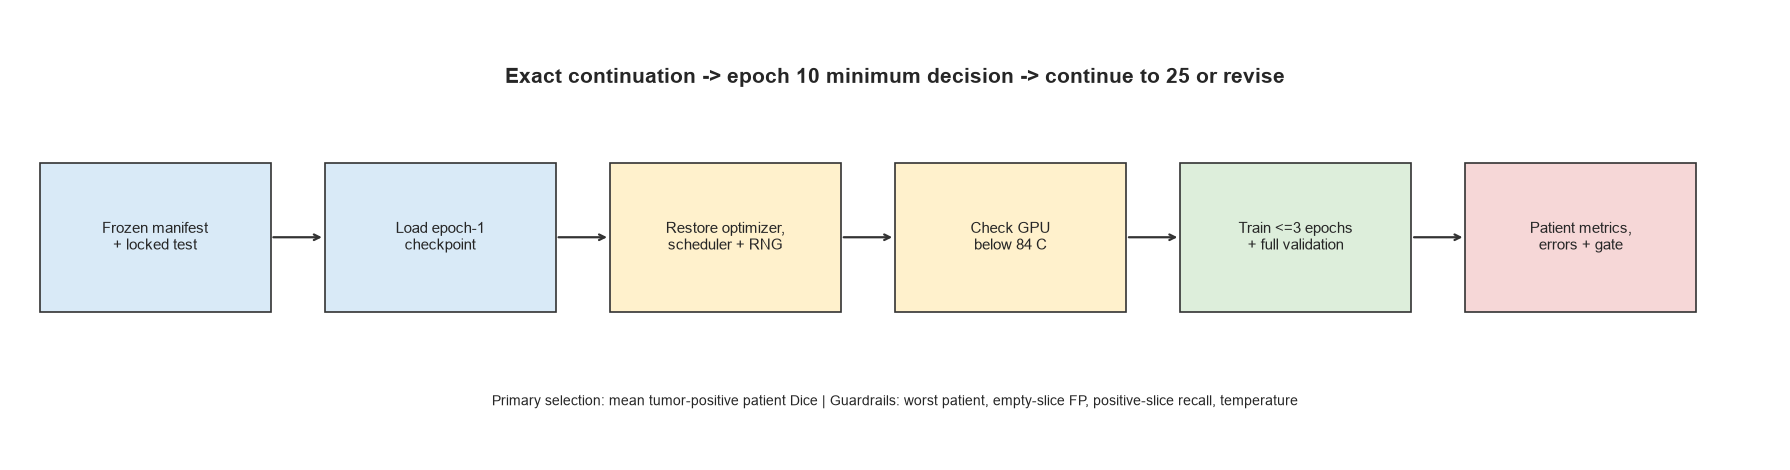

In [2]:

fig, axis = plt.subplots(figsize=(18, 4.8))
axis.set_xlim(0, 18)
axis.set_ylim(0, 5)
axis.axis("off")

steps = [
    (0.3, "Frozen manifest\n+ locked test", "#D9EAF7"),
    (3.2, "Load epoch-1\ncheckpoint", "#D9EAF7"),
    (6.1, "Restore optimizer,\nscheduler + RNG", "#FFF1CC"),
    (9.0, "Check GPU\nbelow 84 C", "#FFF1CC"),
    (11.9, "Train <=3 epochs\n+ full validation", "#DDEEDB"),
    (14.8, "Patient metrics,\nerrors + gate", "#F6D7D7"),
]
for x, label, color in steps:
    patch = plt.Rectangle(
        (x, 1.65), 2.35, 1.65, facecolor=color,
        edgecolor="#333333", linewidth=1.2
    )
    axis.add_patch(patch)
    axis.text(x + 1.175, 2.475, label, ha="center", va="center", fontsize=11)
for (left, _, _), (right, _, _) in zip(steps[:-1], steps[1:]):
    axis.annotate(
        "", xy=(right, 2.475), xytext=(left + 2.35, 2.475),
        arrowprops={"arrowstyle": "->", "linewidth": 1.6, "color": "#333333"},
    )
axis.text(
    9, 4.25,
    "Exact continuation -> epoch 10 minimum decision -> continue to 25 or revise",
    ha="center", va="center", fontsize=15, weight="bold",
)
axis.text(
    9, 0.65,
    "Primary selection: mean tumor-positive patient Dice | "
    "Guardrails: worst patient, empty-slice FP, positive-slice recall, temperature",
    ha="center", va="center", fontsize=10,
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "continuation_process_map.png", dpi=160, bbox_inches="tight")
plt.show()


## Data

The verified manifest is loaded exactly as before. Sampling weights are derived
only from training rows. The natural validation loader remains unweighted and
ordered, so all baseline comparisons use identical validation data.


In [3]:
from src.framework.data.manifest_dataset import VerifiedManifestDataset


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


manifest_hash = sha256_file(MANIFEST_PATH)
assert manifest_hash == EXPECTED_MANIFEST_SHA256
manifest = pd.read_csv(MANIFEST_PATH)
assert len(manifest) == 58_638
assert manifest["sample_id"].is_unique
assert manifest["verification_status"].eq("verified").all()
assert manifest["manual_spatial_status"].eq("approved").all()

try:
    VerifiedManifestDataset(MANIFEST_PATH, split="test", root_dir=DATASET_ROOT)
except PermissionError as exc:
    print(f"PASS: test split locked: {exc}")
else:
    raise AssertionError("Test split opened without explicit authorization.")

volume_sets = {
    split: set(manifest.loc[manifest["split"].eq(split), "volume_id"])
    for split in ("train", "val", "test")
}
assert volume_sets["train"].isdisjoint(volume_sets["val"])
assert volume_sets["train"].isdisjoint(volume_sets["test"])
assert volume_sets["val"].isdisjoint(volume_sets["test"])
print(f"PASS: frozen manifest {manifest_hash[:12]}... and patient isolation verified.")

PASS: test split locked: Test data access is locked. Pass allow_test=True only for the one-time held-out evaluation after model decisions are frozen.
PASS: frozen manifest 575a6fc391d6... and patient isolation verified.


### 2. Define paired training augmentation

The transform uses bilinear interpolation for images and nearest-neighbour interpolation for masks. Validation receives no transform.

In [4]:
class PairedTrainingAugment:
    def __init__(
        self,
        flip_probability=0.30,
        affine_probability=0.60,
        max_rotation_degrees=10.0,
        max_translation_fraction=0.05,
        scale_range=(0.95, 1.05),
        intensity_probability=0.50,
        brightness_shift=0.05,
        contrast_range=(0.90, 1.10),
    ):
        self.flip_probability = flip_probability
        self.affine_probability = affine_probability
        self.max_rotation_degrees = max_rotation_degrees
        self.max_translation_fraction = max_translation_fraction
        self.scale_range = scale_range
        self.intensity_probability = intensity_probability
        self.brightness_shift = brightness_shift
        self.contrast_range = contrast_range

    def __call__(self, image: np.ndarray, mask: np.ndarray):
        image = np.asarray(image, dtype=np.float32)
        mask = np.asarray(mask, dtype=np.float32)

        if random.random() < self.flip_probability:
            image = np.fliplr(image).copy()
            mask = np.fliplr(mask).copy()

        if random.random() < self.affine_probability:
            height, width = image.shape
            angle = random.uniform(-self.max_rotation_degrees, self.max_rotation_degrees)
            scale = random.uniform(*self.scale_range)
            tx = random.uniform(-self.max_translation_fraction, self.max_translation_fraction) * width
            ty = random.uniform(-self.max_translation_fraction, self.max_translation_fraction) * height
            matrix = cv2.getRotationMatrix2D((width / 2, height / 2), angle, scale)
            matrix[:, 2] += (tx, ty)
            image = cv2.warpAffine(
                image, matrix, (width, height), flags=cv2.INTER_LINEAR,
                borderMode=cv2.BORDER_CONSTANT, borderValue=0,
            )
            mask = cv2.warpAffine(
                mask, matrix, (width, height), flags=cv2.INTER_NEAREST,
                borderMode=cv2.BORDER_CONSTANT, borderValue=0,
            )

        if random.random() < self.intensity_probability:
            contrast = random.uniform(*self.contrast_range)
            brightness = random.uniform(-self.brightness_shift, self.brightness_shift)
            image = np.clip(image * contrast + brightness, 0.0, 1.0)

        mask = (mask > 0.5).astype(np.float32)
        return np.ascontiguousarray(image), np.ascontiguousarray(mask)


train_transform = PairedTrainingAugment()

### 3. Build the patient-and-lesion-balanced training sampler

In [5]:
train_dataset = VerifiedManifestDataset(
    MANIFEST_PATH, split="train", root_dir=DATASET_ROOT,
    target="tumor", transform=train_transform, validate_paths=True,
)
val_dataset = VerifiedManifestDataset(
    MANIFEST_PATH, split="val", root_dir=DATASET_ROOT,
    target="tumor", transform=None, validate_paths=True,
)

train_rows = pd.DataFrame([
    {
        "sample_id": row["sample_id"],
        "volume_id": int(row["volume_id"]),
        "tumor_pixels": int(row["tumor_pixels"]),
    }
    for row in train_dataset.rows
])
if train_rows["sample_id"].tolist() != train_dataset.sample_ids:
    raise RuntimeError("Training manifest order does not match dataset order.")

positive_mask = train_rows["tumor_pixels"].gt(0)
positive_pixels = train_rows.loc[positive_mask, "tumor_pixels"]
quartile_edges = positive_pixels.quantile([0.25, 0.50, 0.75]).to_numpy()
train_rows["lesion_stratum"] = 0
train_rows.loc[positive_mask, "lesion_stratum"] = (
    np.searchsorted(quartile_edges, positive_pixels.to_numpy(), side="right") + 1
)

volume_counts = train_rows.groupby("volume_id")["sample_id"].transform("count")
inverse_volume_factor = len(train_rows) / (
    train_rows["volume_id"].nunique() * volume_counts
)
lesion_factor = train_rows["lesion_stratum"].map(LESION_FACTORS).astype(float)
raw_weights = inverse_volume_factor * lesion_factor
normalized_weights = raw_weights / raw_weights.mean()
train_rows["sampling_weight"] = normalized_weights.clip(
    MIN_NORMALIZED_WEIGHT, MAX_NORMALIZED_WEIGHT
)

train_flags = positive_mask.to_numpy()
weights = train_rows["sampling_weight"].to_numpy(dtype=np.float64)
sampler_generator = torch.Generator().manual_seed(SEED)
train_sampler = WeightedRandomSampler(
    torch.as_tensor(weights, dtype=torch.double),
    num_samples=len(train_dataset), replacement=True,
    generator=sampler_generator,
)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset, batch_size=VALIDATION_BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)

preview_indices = np.asarray(list(iter(train_sampler))[: min(12000, len(train_dataset))])
natural_distribution = (
    train_rows.groupby("lesion_stratum").size().rename("natural_count")
)
sampled_distribution = (
    train_rows.iloc[preview_indices].groupby("lesion_stratum").size().rename("sampled_count")
)
sampling_audit = pd.concat(
    [natural_distribution, sampled_distribution], axis=1
).fillna(0)
sampling_audit["natural_pct"] = 100 * sampling_audit["natural_count"] / sampling_audit["natural_count"].sum()
sampling_audit["sampled_pct"] = 100 * sampling_audit["sampled_count"] / sampling_audit["sampled_count"].sum()
sampling_audit.index = ["empty", "Q1 smallest", "Q2", "Q3", "Q4 largest"]

volume_audit = train_rows.groupby("volume_id").agg(
    slices=("sample_id", "size"),
    positives=("tumor_pixels", lambda values: int((values > 0).sum())),
    mean_weight=("sampling_weight", "mean"),
)
sampled_volume_share = (
    train_rows.iloc[preview_indices]["volume_id"].value_counts(normalize=True)
    .mul(100).rename("sampled_pct")
)
volume_audit = volume_audit.join(sampled_volume_share).fillna({"sampled_pct": 0})

display(sampling_audit.style.format({
    "natural_pct": "{:.2f}%", "sampled_pct": "{:.2f}%"
}))
print(
    f"Train={len(train_dataset):,} | Validation={len(val_dataset):,} | "
    f"training volumes={train_rows['volume_id'].nunique()}"
)


,natural_count,sampled_count,natural_pct,sampled_pct
empty,35737,7605,87.88%,63.38%
Q1 smallest,1212,1686,2.98%,14.05%
Q2,1245,1325,3.06%,11.04%
Q3,1240,829,3.05%,6.91%
Q4 largest,1233,555,3.03%,4.62%


Train=40,667 | Validation=10,685 | training volumes=104


### 4. Visualize sampler behavior and augmentation integrity

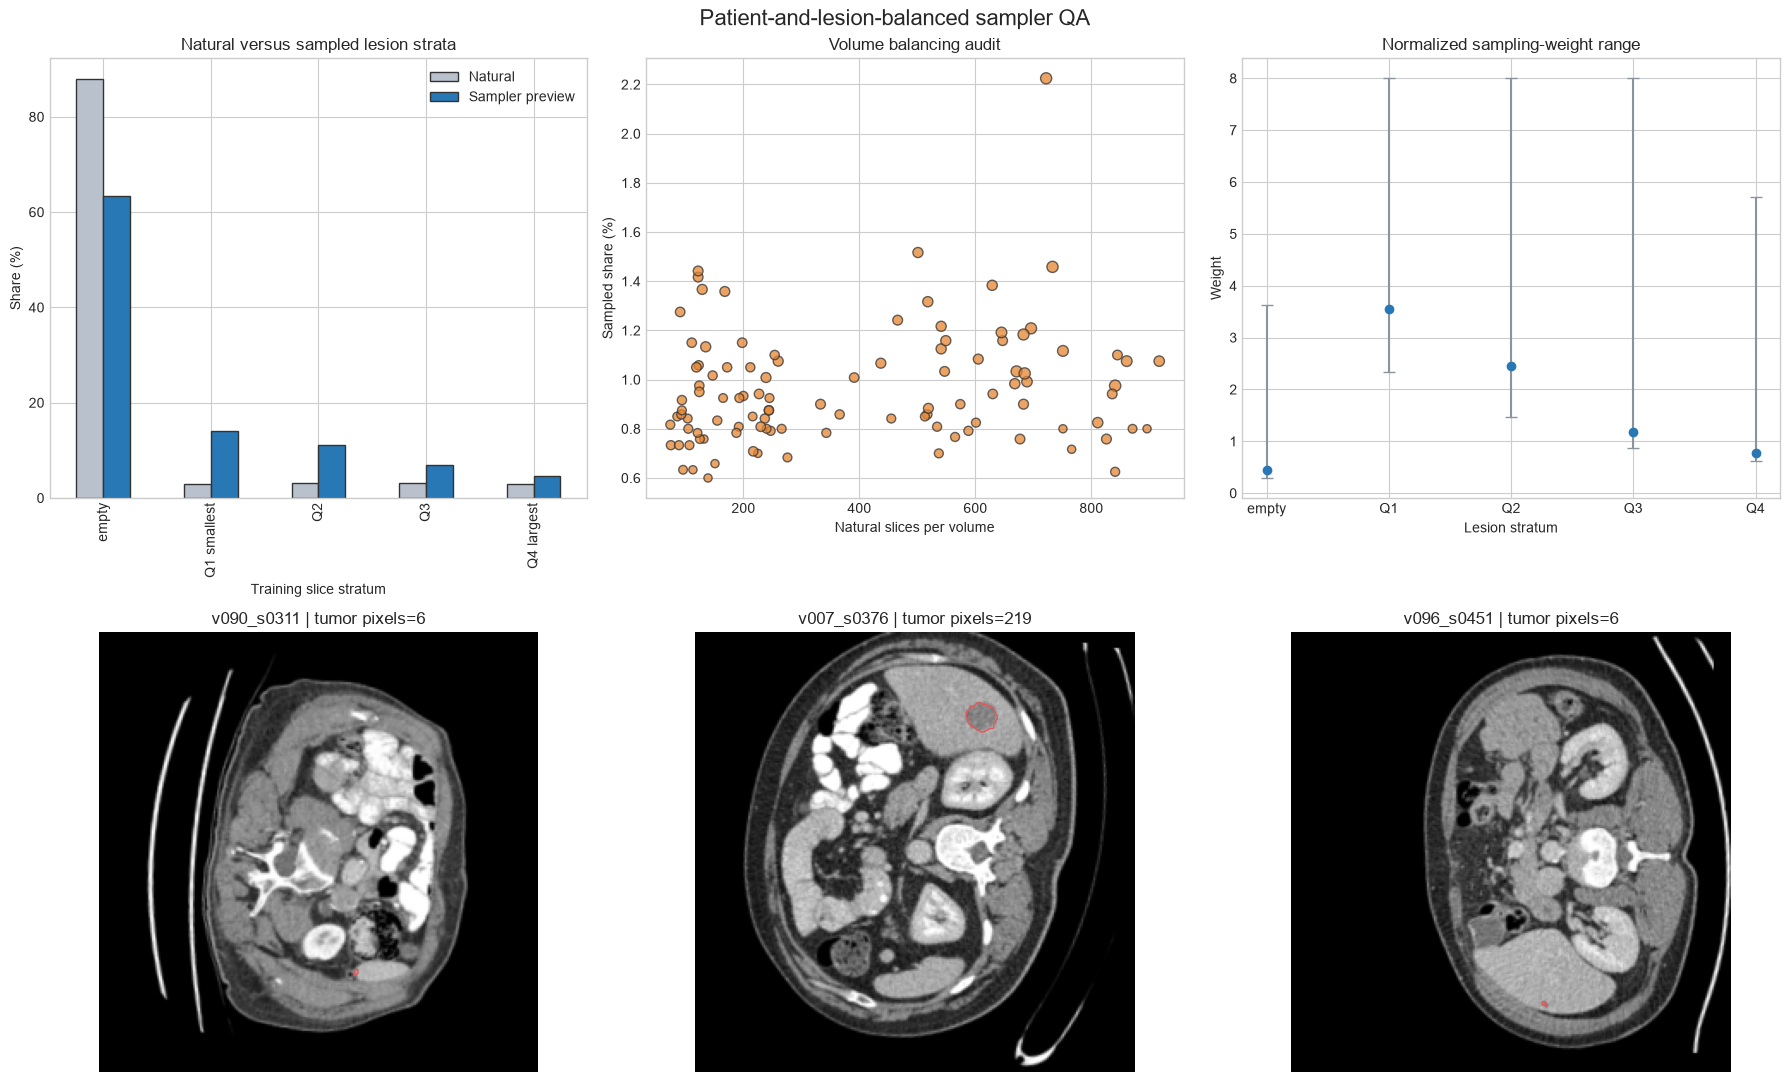

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

sampling_audit[["natural_pct", "sampled_pct"]].plot.bar(
    ax=axes[0, 0], color=["#B9C2CC", "#2878B5"], edgecolor="#333333"
)
axes[0, 0].set_title("Natural versus sampled lesion strata")
axes[0, 0].set_xlabel("Training slice stratum"); axes[0, 0].set_ylabel("Share (%)")
axes[0, 0].legend(["Natural", "Sampler preview"])

axes[0, 1].scatter(
    volume_audit["slices"], volume_audit["sampled_pct"],
    s=35 + 2 * np.sqrt(volume_audit["positives"]), alpha=0.75,
    color="#E68632", edgecolor="#333333",
)
axes[0, 1].set_title("Volume balancing audit")
axes[0, 1].set_xlabel("Natural slices per volume")
axes[0, 1].set_ylabel("Sampled share (%)")

weight_by_stratum = train_rows.groupby("lesion_stratum")["sampling_weight"].agg(
    ["median", "min", "max"]
)
axes[0, 2].errorbar(
    np.arange(len(weight_by_stratum)), weight_by_stratum["median"],
    yerr=[
        weight_by_stratum["median"] - weight_by_stratum["min"],
        weight_by_stratum["max"] - weight_by_stratum["median"],
    ],
    fmt="o", capsize=4, color="#2878B5", ecolor="#8A949E",
)
axes[0, 2].set_xticks(
    np.arange(len(weight_by_stratum)),
    ["empty", "Q1", "Q2", "Q3", "Q4"],
)
axes[0, 2].set_title("Normalized sampling-weight range")
axes[0, 2].set_xlabel("Lesion stratum"); axes[0, 2].set_ylabel("Weight")

positive_indices = np.flatnonzero(train_flags)
preview_source_indices = np.random.default_rng(SEED).choice(
    positive_indices, size=min(3, len(positive_indices)), replace=False
)
for axis, source_index in zip(axes[1], preview_source_indices):
    sample = train_dataset[int(source_index)]
    image = sample["image"][0].numpy()
    mask = sample["mask"][0].numpy()
    axis.imshow(image, cmap="gray")
    axis.contour(mask, levels=[0.5], colors=["#E15759"], linewidths=1.0)
    axis.set_title(
        f"{sample['sample_id']} | tumor pixels={int(mask.sum()):,}"
    )
    axis.axis("off")

fig.suptitle("Patient-and-lesion-balanced sampler QA", fontsize=16)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "sampler_audit.png", dpi=160, bbox_inches="tight")
plt.show()


## Results

### 5. Define patient-aware evaluation and exact-resume utilities

In [7]:
from src.framework.losses.focal_dice import FocalDiceLoss
from src.framework.models.mobilenetv2_unet import MobileNetV2UNet


def gpu_stats():
    if not torch.cuda.is_available():
        return {"temperature_c": np.nan, "utilization_pct": np.nan, "memory_mb": np.nan}
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=temperature.gpu,utilization.gpu,memory.used",
             "--format=csv,noheader,nounits"],
            capture_output=True, text=True, check=True,
        )
        values = [float(value.strip()) for value in result.stdout.splitlines()[0].split(",")]
        return {"temperature_c": values[0], "utilization_pct": values[1], "memory_mb": values[2]}
    except Exception:
        return {"temperature_c": np.nan, "utilization_pct": np.nan, "memory_mb": np.nan}



def append_thermal_log(record: dict):
    path = OUTPUT_DIR / "thermal_cooldown_log.csv"
    frame = pd.DataFrame([record])
    if path.is_file():
        existing = pd.read_csv(path)
        frame = pd.concat([existing, frame], ignore_index=True)
    frame.to_csv(path, index=False)


def wait_for_gpu_cool(epoch: int) -> bool:
    """Wait in bounded 30-second checks until the next epoch is thermally safe."""
    if not torch.cuda.is_available():
        return True
    started_wait = time.time()
    max_wait_seconds = MAX_COOLDOWN_MINUTES * 60
    while True:
        thermal = gpu_stats()
        elapsed = time.time() - started_wait
        append_thermal_log({
            "timestamp": pd.Timestamp.now().isoformat(),
            "target_epoch": int(epoch),
            "temperature_c": thermal["temperature_c"],
            "utilization_pct": thermal["utilization_pct"],
            "memory_mb": thermal["memory_mb"],
            "cooldown_elapsed_seconds": elapsed,
        })
        temperature = thermal["temperature_c"]
        if not np.isfinite(temperature) or temperature < MAX_START_GPU_TEMP_C:
            print(
                f"READY: epoch {epoch} starts at "
                f"{temperature:.0f}C." if np.isfinite(temperature)
                else f"READY: epoch {epoch}; temperature unavailable."
            )
            return True
        if elapsed >= max_wait_seconds:
            return False
        print(
            f"COOLING: GPU {temperature:.0f}C; waiting "
            f"{COOLDOWN_POLL_SECONDS}s before epoch {epoch}."
        )
        time.sleep(COOLDOWN_POLL_SECONDS)

def evaluate_patient_aware(model, loader, criterion, device, threshold=0.5, collect_rows=False):
    model.eval()
    loss_sum = intersection = predicted = actual = 0.0
    positive_seen = positive_detected = positive_empty = 0
    empty_seen = empty_with_fp = 0
    patient = {}
    rows = []
    with torch.inference_mode():
        for batch in loader:
            images = batch["image"].to(device, non_blocking=True)
            masks = batch["mask"].to(device, non_blocking=True)
            logits = model(images)
            probabilities = torch.sigmoid(logits)
            predictions = probabilities >= threshold
            truth = masks >= 0.5
            loss_sum += float(criterion(logits, masks)) * images.shape[0]
            intersection += float((predictions & truth).sum())
            predicted += float(predictions.sum())
            actual += float(truth.sum())

            for index, sample_id in enumerate(batch["sample_id"]):
                volume_id = int(batch["volume_id"][index])
                true_px = int(truth[index].sum())
                pred_px = int(predictions[index].sum())
                inter_px = int((predictions[index] & truth[index]).sum())
                dice = (2 * inter_px + 1e-6) / (pred_px + true_px + 1e-6)
                accumulator = patient.setdefault(
                    volume_id, {"intersection": 0, "predicted": 0, "true": 0,
                                "positive_slices": 0, "detected": 0, "positive_empty": 0,
                                "empty_slices": 0, "empty_with_fp": 0}
                )
                accumulator["intersection"] += inter_px
                accumulator["predicted"] += pred_px
                accumulator["true"] += true_px
                if true_px > 0:
                    positive_seen += 1
                    positive_detected += int(inter_px > 0)
                    positive_empty += int(pred_px == 0)
                    accumulator["positive_slices"] += 1
                    accumulator["detected"] += int(inter_px > 0)
                    accumulator["positive_empty"] += int(pred_px == 0)
                else:
                    empty_seen += 1
                    empty_with_fp += int(pred_px > 0)
                    accumulator["empty_slices"] += 1
                    accumulator["empty_with_fp"] += int(pred_px > 0)
                if collect_rows:
                    rows.append({
                        "sample_id": sample_id, "volume_id": volume_id,
                        "slice_index": int(batch["slice_index"][index]),
                        "true_pixels": true_px, "predicted_pixels": pred_px,
                        "intersection_pixels": inter_px, "dice": dice,
                        "mean_probability": float(probabilities[index].mean()),
                        "max_probability": float(probabilities[index].max()),
                    })

    patient_rows = []
    for volume_id, values in sorted(patient.items()):
        denominator = values["predicted"] + values["true"]
        patient_rows.append({
            "volume_id": volume_id,
            "micro_dice": (
                (2 * values["intersection"] + 1e-6) / (denominator + 1e-6)
            ),
            "true_pixels": values["true"],
            "predicted_pixels": values["predicted"],
            "positive_slices": values["positive_slices"],
            "positive_slice_recall": values["detected"] / max(values["positive_slices"], 1),
            "positive_predicted_empty_pct": 100 * values["positive_empty"] / max(values["positive_slices"], 1),
            "empty_slice_false_positive_pct": 100 * values["empty_with_fp"] / max(values["empty_slices"], 1),
        })
    patient_frame = pd.DataFrame(patient_rows)
    tumor_positive_patients = patient_frame.loc[patient_frame["true_pixels"].gt(0)]
    return {
        "loss": loss_sum / len(loader.dataset),
        "global_micro_dice": float((2 * intersection + 1e-6) / (predicted + actual + 1e-6)),
        "pixel_precision": float((intersection + 1e-6) / (predicted + 1e-6)),
        "pixel_recall": float((intersection + 1e-6) / (actual + 1e-6)),
        "positive_slice_recall": positive_detected / max(positive_seen, 1),
        "positive_predicted_empty_pct": 100 * positive_empty / max(positive_seen, 1),
        "empty_slice_false_positive_pct": 100 * empty_with_fp / max(empty_seen, 1),
        "mean_patient_dice": float(tumor_positive_patients["micro_dice"].mean()),
        "median_patient_dice": float(tumor_positive_patients["micro_dice"].median()),
        "worst_patient_dice": float(tumor_positive_patients["micro_dice"].min()),
        "predicted_pixels": int(predicted), "true_pixels": int(actual),
        "patient_rows": patient_rows, "rows": rows,
    }


def capture_rng_state():
    return {
        "python_random_state": random.getstate(),
        "numpy_random_state": np.random.get_state(),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state_all": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        "sampler_generator_state": sampler_generator.get_state(),
    }


def restore_rng_state(payload):
    random.setstate(payload["python_random_state"])
    np.random.set_state(payload["numpy_random_state"])
    torch.set_rng_state(payload["torch_rng_state"].detach().cpu().to(torch.uint8))
    if torch.cuda.is_available() and payload.get("cuda_rng_state_all") is not None:
        torch.cuda.set_rng_state_all([
            state.detach().cpu().to(torch.uint8)
            for state in payload["cuda_rng_state_all"]
        ])
    sampler_generator.set_state(
        payload["sampler_generator_state"].detach().cpu().to(torch.uint8)
    )


def save_checkpoint(path, model, optimizer, scheduler, scaler, epoch, history, patient_history, best_score, stale_epochs):
    torch.save({
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict(),
        "epoch": int(epoch), "history": history,
        "patient_history": patient_history,
        "best_mean_patient_dice": float(best_score),
        "stale_epochs": int(stale_epochs),
        "rng_state": capture_rng_state(),
        "manifest_sha256": manifest_hash,
        "configuration": {
            "epochs": EPOCHS, "learning_rate": LEARNING_RATE,
            "sampler_strategy": SAMPLER_STRATEGY,
            "fixed_threshold": FIXED_THRESHOLD,
        },
    }, path)

### 6. Train, validate, checkpoint, cool, and resume

The cell pauses when temperature is at or above the limit. Rerun this cell after cooling.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
amp_enabled = bool(USE_MIXED_PRECISION and device.type == "cuda")
model = MobileNetV2UNet(
    in_channels=1, out_channels=1, pretrained=USE_PRETRAINED_ENCODER
).to(device)
criterion = FocalDiceLoss(
    focal_alpha=0.75, focal_gamma=2.0, focal_weight=0.5, dice_weight=0.5
)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=MIN_LEARNING_RATE
)
scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

last_checkpoint = OUTPUT_DIR / "patient_aware_last.pth"
best_checkpoint = OUTPUT_DIR / "patient_aware_best.pth"
history, patient_history = [], []
start_epoch, stale_epochs = 1, 0
best_mean_patient_dice = -1.0

if RESUME_IF_AVAILABLE and last_checkpoint.is_file():
    checkpoint = torch.load(last_checkpoint, map_location=device, weights_only=False)
    if checkpoint.get("manifest_sha256") != manifest_hash:
        raise RuntimeError("Checkpoint manifest differs from the frozen dataset.")
    expected_configuration = {
        "epochs": EPOCHS, "learning_rate": LEARNING_RATE,
        "sampler_strategy": SAMPLER_STRATEGY,
        "fixed_threshold": FIXED_THRESHOLD,
    }
    if checkpoint.get("configuration") != expected_configuration:
        raise RuntimeError(
            "Existing checkpoint configuration differs from this notebook. "
            "Use a new output directory for a changed experiment."
        )
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])
    scaler.load_state_dict(checkpoint.get("scaler_state", {}))
    history = list(checkpoint.get("history", []))
    patient_history = list(checkpoint.get("patient_history", []))
    best_mean_patient_dice = float(checkpoint.get("best_mean_patient_dice", -1))
    stale_epochs = int(checkpoint.get("stale_epochs", 0))
    start_epoch = int(checkpoint["epoch"]) + 1
    restore_rng_state(checkpoint["rng_state"])
    print(f"Resuming exactly at epoch {start_epoch}; best patient Dice={best_mean_patient_dice:.4f}.")

stop_reason = "not_started"
if RUN_TRAINING and start_epoch <= EPOCHS:
    started = time.perf_counter()
    try:
        session_end_epoch = min(EPOCHS, TARGET_DECISION_EPOCH)
        for epoch in range(start_epoch, session_end_epoch + 1):
            cooled = wait_for_gpu_cool(epoch)
            if not cooled:
                stop_reason = 'cooldown_timeout'
                print(
                    f'WAIT: GPU did not cool below {MAX_START_GPU_TEMP_C}C within '
                    f'{MAX_COOLDOWN_MINUTES} minutes. Check ventilation and rerun later.'
                )
                break
            model.train()
            train_loss_sum = 0.0
            for batch in train_loader:
                images = batch["image"].to(device, non_blocking=True)
                masks = batch["mask"].to(device, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=amp_enabled):
                    logits = model(images)
                    loss = criterion(logits, masks)
                if not torch.isfinite(loss):
                    raise FloatingPointError(f"Non-finite loss at epoch {epoch}.")
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                scaler.step(optimizer)
                scaler.update()
                train_loss_sum += float(loss.detach()) * images.shape[0]

            validation = evaluate_patient_aware(
                model, val_loader, criterion, device, FIXED_THRESHOLD
            )
            thermal = gpu_stats()
            record = {
                "epoch": epoch,
                "train_loss": train_loss_sum / len(train_dataset),
                "val_loss": validation["loss"],
                "val_global_micro_dice": validation["global_micro_dice"],
                "val_mean_patient_dice": validation["mean_patient_dice"],
                "val_median_patient_dice": validation["median_patient_dice"],
                "val_worst_patient_dice": validation["worst_patient_dice"],
                "val_pixel_precision": validation["pixel_precision"],
                "val_pixel_recall": validation["pixel_recall"],
                "val_positive_slice_recall": validation["positive_slice_recall"],
                "val_positive_predicted_empty_pct": validation["positive_predicted_empty_pct"],
                "val_empty_slice_false_positive_pct": validation["empty_slice_false_positive_pct"],
                "lr": optimizer.param_groups[0]["lr"], **thermal,
                "elapsed_seconds": time.perf_counter() - started,
            }
            history.append(record)
            for patient_row in validation["patient_rows"]:
                patient_history.append({"epoch": epoch, **patient_row})

            improved = validation["mean_patient_dice"] > (
                best_mean_patient_dice + EARLY_STOPPING_MIN_DELTA
            )
            if improved:
                best_mean_patient_dice = validation["mean_patient_dice"]
                stale_epochs = 0
            else:
                stale_epochs += 1
            scheduler.step()

            pd.DataFrame(history).to_csv(OUTPUT_DIR / "patient_aware_history.csv", index=False)
            pd.DataFrame(patient_history).to_csv(OUTPUT_DIR / "patient_metrics_by_epoch.csv", index=False)
            save_checkpoint(
                last_checkpoint, model, optimizer, scheduler, scaler, epoch,
                history, patient_history, best_mean_patient_dice, stale_epochs,
            )
            if improved:
                save_checkpoint(
                    best_checkpoint, model, optimizer, scheduler, scaler, epoch,
                    history, patient_history, best_mean_patient_dice, stale_epochs,
                )

            print(
                f"epoch={epoch:02d} train={record['train_loss']:.4f} "
                f"val={record['val_loss']:.4f} global={record['val_global_micro_dice']:.4f} "
                f"patient_mean={record['val_mean_patient_dice']:.4f} "
                f"worst={record['val_worst_patient_dice']:.4f} "
                f"temp={thermal['temperature_c']:.0f}C"
            )

            if np.isfinite(thermal["temperature_c"]) and thermal["temperature_c"] >= EMERGENCY_STOP_TEMP_C:
                stop_reason = "emergency_thermal_stop"
                print(
                    f"STOP: GPU reached {thermal['temperature_c']:.0f}C. "
                    "The completed epoch is saved; inspect cooling before resuming."
                )
                break
            if np.isfinite(thermal["temperature_c"]) and thermal["temperature_c"] >= COOLDOWN_WARNING_TEMP_C:
                print(
                    f"COOLDOWN: GPU reached {thermal['temperature_c']:.0f}C. "
                    "The next epoch will wait for a safe start temperature."
                )
            if (
                epoch >= MIN_EPOCHS_BEFORE_EARLY_STOP
                and stale_epochs >= EARLY_STOPPING_PATIENCE
            ):
                stop_reason = "early_stopping"
                print("STOP: patient-level validation metric stopped improving.")
                break
        else:
            stop_reason = (
                'completed_25_epochs'
                if session_end_epoch >= EPOCHS
                else 'epoch_10_decision_point_reached'
            )
    except KeyboardInterrupt:
        stop_reason = "interrupted_safely"
        print("Interrupted safely; the last completed epoch is preserved.")
elif start_epoch > EPOCHS:
    stop_reason = "already_completed"
else:
    stop_reason = "training_disabled"

history_frame = pd.read_csv(OUTPUT_DIR / "patient_aware_history.csv") if (
    OUTPUT_DIR / "patient_aware_history.csv"
).is_file() else pd.DataFrame()
patient_history_frame = pd.read_csv(OUTPUT_DIR / "patient_metrics_by_epoch.csv") if (
    OUTPUT_DIR / "patient_metrics_by_epoch.csv"
).is_file() else pd.DataFrame()
display(history_frame.tail(10))
print(f"Stop reason: {stop_reason}")

READY: epoch 1 starts at 63C.
epoch=01 train=0.4582 val=0.4856 global=0.4120 patient_mean=0.2470 worst=0.0162 temp=87C
COOLING: GPU 85C; waiting 30s before epoch 2.
READY: epoch 2 starts at 73C.
epoch=02 train=0.4173 val=0.4835 global=0.5145 patient_mean=0.3117 worst=0.0180 temp=87C
COOLING: GPU 86C; waiting 30s before epoch 3.
READY: epoch 3 starts at 74C.
epoch=03 train=0.4055 val=0.4835 global=0.5206 patient_mean=0.3342 worst=0.0039 temp=87C
COOLING: GPU 86C; waiting 30s before epoch 4.
READY: epoch 4 starts at 78C.
epoch=04 train=0.3967 val=0.4837 global=0.5217 patient_mean=0.3478 worst=0.0014 temp=87C
COOLING: GPU 87C; waiting 30s before epoch 5.
READY: epoch 5 starts at 75C.
epoch=05 train=0.3926 val=0.4834 global=0.5205 patient_mean=0.3352 worst=0.0026 temp=86C
COOLING: GPU 85C; waiting 30s before epoch 6.
READY: epoch 6 starts at 74C.
epoch=06 train=0.3873 val=0.4867 global=0.4495 patient_mean=0.3198 worst=0.0019 temp=86C
COOLING: GPU 86C; waiting 30s before epoch 7.
READY: epo

,epoch,train_loss,val_loss,val_global_micro_dice,val_mean_patient_dice,val_median_patient_dice,val_worst_patient_dice,val_pixel_precision,val_pixel_recall,val_positive_slice_recall,val_positive_predicted_empty_pct,val_empty_slice_false_positive_pct,lr,temperature_c,utilization_pct,memory_mb,elapsed_seconds
0,1,0.458238,0.485554,0.412006,0.247023,0.099480,1.620089e-02,0.412828,0.411188,0.682342,16.794626,38.162398,0.000300,87.0,78.0,1104.0,474.285716
1,2,0.417308,0.483480,0.514485,0.311651,0.179329,1.797968e-02,0.574550,0.465789,0.738964,9.884837,20.958208,0.000299,87.0,67.0,1680.0,984.012229
2,3,0.405469,0.483479,0.520588,0.334225,0.331650,3.910368e-03,0.664429,0.427943,0.682342,16.506718,18.199730,0.000295,87.0,63.0,1680.0,1497.636640
3,4,0.396699,0.483724,0.521742,0.347844,0.361709,1.412834e-03,0.721302,0.408675,0.647793,19.001919,17.432334,0.000290,87.0,65.0,1680.0,2027.370610
4,5,0.392640,0.483366,0.520547,0.335228,0.300590,2.590512e-03,0.653417,0.432583,0.667946,17.466411,29.565488,0.000282,86.0,70.0,1680.0,2553.155261
5,6,0.387303,0.486679,0.449547,0.319758,0.299079,1.896101e-03,0.700481,0.330980,0.624760,21.880998,18.832314,0.000272,86.0,66.0,1680.0,3077.197864
6,7,0.383959,0.483286,0.524200,0.356189,0.354597,1.856126e-03,0.673402,0.429121,0.649712,19.289827,17.826403,0.000260,87.0,54.0,1680.0,3594.124915
7,8,0.381919,0.484849,0.482258,0.294078,0.093799,9.044702e-03,0.614704,0.396769,0.679463,14.011516,26.775900,0.000246,87.0,71.0,1680.0,4111.639539
8,9,0.378611,0.483820,0.528480,0.353924,0.328258,1.307609e-03,0.691452,0.427678,0.646833,13.435701,17.276781,0.000231,87.0,55.0,1680.0,4628.954472
9,10,0.361116,0.478427,0.462554,0.296433,0.376460,6.526819e-12,0.785341,0.327817,0.491363,44.625720,3.038474,0.000215,87.0,65.0,1680.0,5140.987105


Stop reason: epoch_10_decision_point_reached


### 7. Visualize learning, patient robustness, detection, and temperature

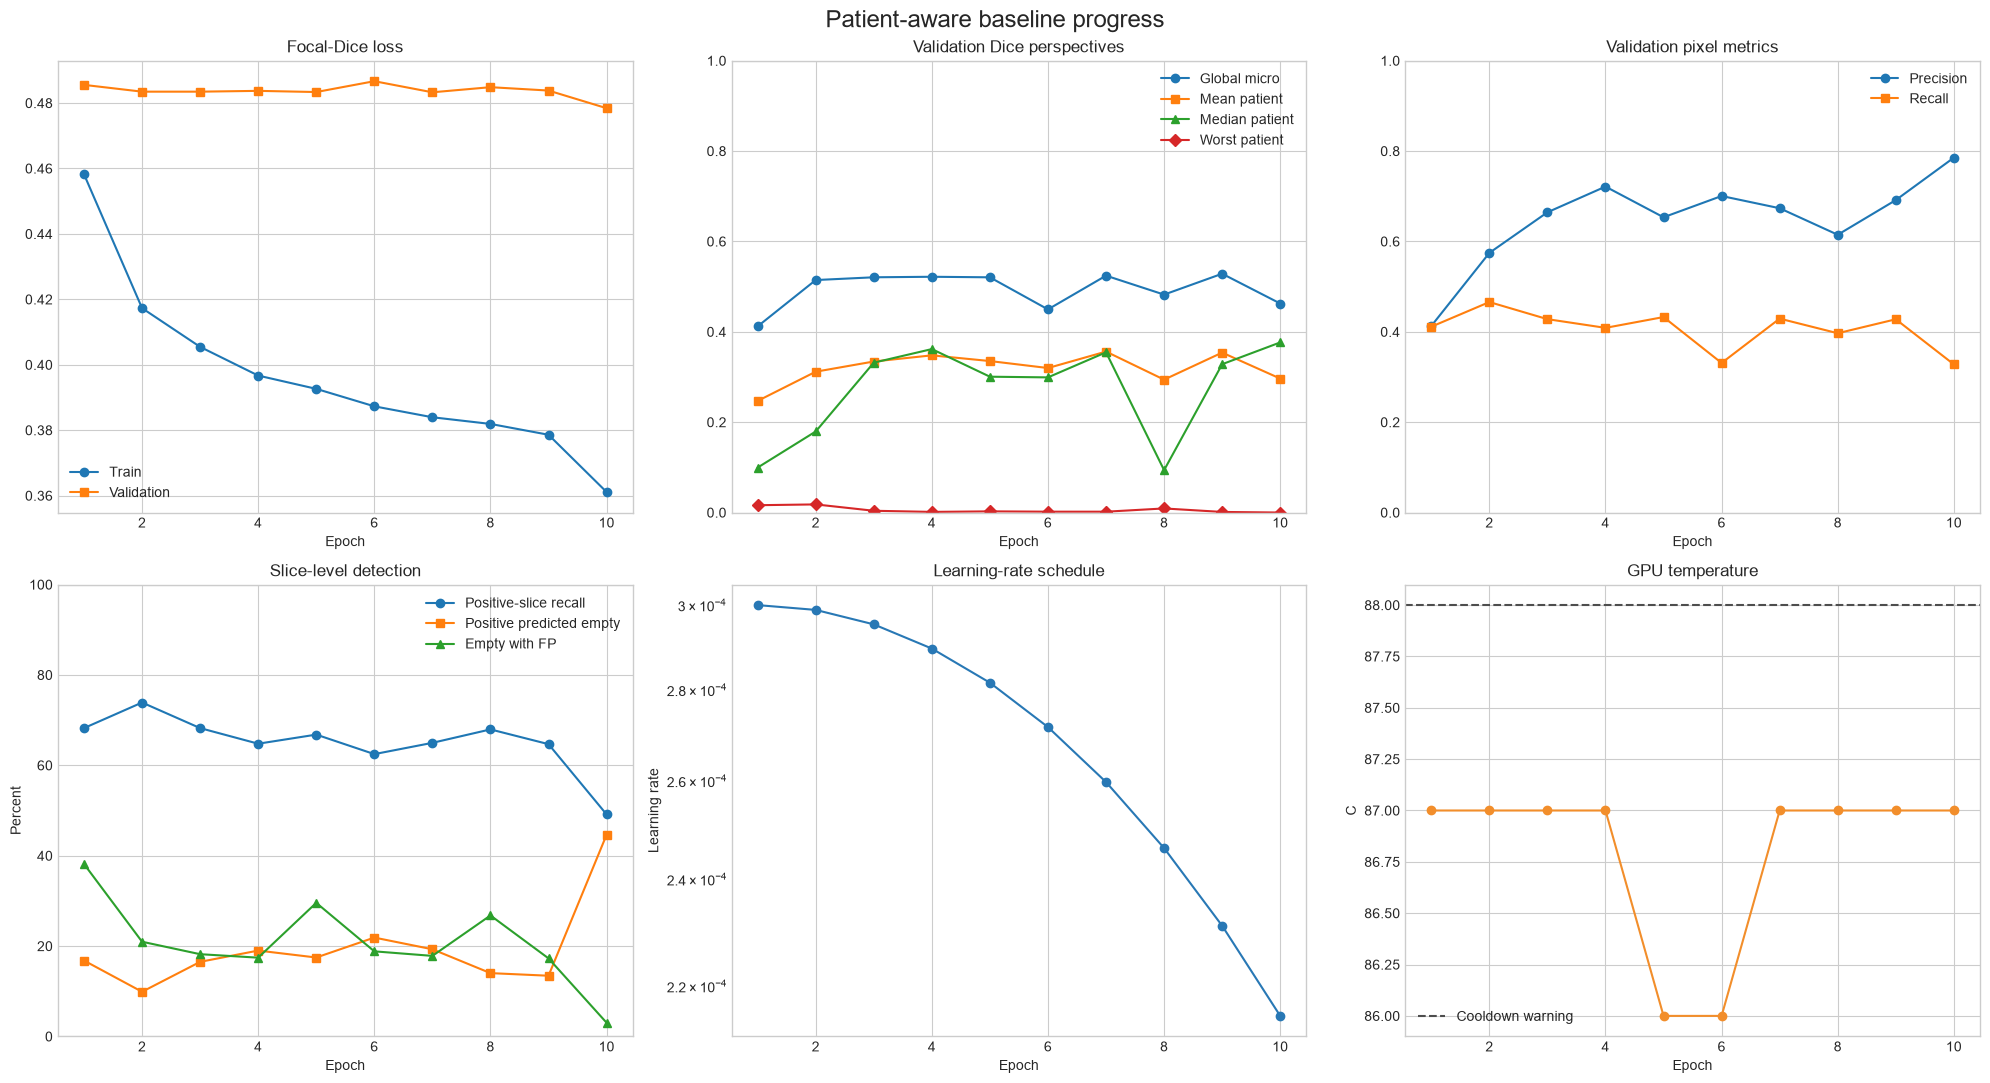

In [9]:
if history_frame.empty:
    print("No history available yet.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(20, 11))
    axes[0, 0].plot(history_frame["epoch"], history_frame["train_loss"], marker="o", label="Train")
    axes[0, 0].plot(history_frame["epoch"], history_frame["val_loss"], marker="s", label="Validation")
    axes[0, 0].set_title("Focal-Dice loss"); axes[0, 0].set_xlabel("Epoch"); axes[0, 0].legend()

    for metric, label, marker in [
        ("val_global_micro_dice", "Global micro", "o"),
        ("val_mean_patient_dice", "Mean patient", "s"),
        ("val_median_patient_dice", "Median patient", "^"),
        ("val_worst_patient_dice", "Worst patient", "D"),
    ]:
        axes[0, 1].plot(history_frame["epoch"], history_frame[metric], marker=marker, label=label)
    axes[0, 1].set_ylim(0, 1); axes[0, 1].set_title("Validation Dice perspectives")
    axes[0, 1].set_xlabel("Epoch"); axes[0, 1].legend()

    axes[0, 2].plot(history_frame["epoch"], history_frame["val_pixel_precision"], marker="o", label="Precision")
    axes[0, 2].plot(history_frame["epoch"], history_frame["val_pixel_recall"], marker="s", label="Recall")
    axes[0, 2].set_ylim(0, 1); axes[0, 2].set_title("Validation pixel metrics")
    axes[0, 2].set_xlabel("Epoch"); axes[0, 2].legend()

    axes[1, 0].plot(history_frame["epoch"], 100 * history_frame["val_positive_slice_recall"], marker="o", label="Positive-slice recall")
    axes[1, 0].plot(history_frame["epoch"], history_frame["val_positive_predicted_empty_pct"], marker="s", label="Positive predicted empty")
    axes[1, 0].plot(history_frame["epoch"], history_frame["val_empty_slice_false_positive_pct"], marker="^", label="Empty with FP")
    axes[1, 0].set_ylim(0, 100); axes[1, 0].set_title("Slice-level detection")
    axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Percent"); axes[1, 0].legend()

    axes[1, 1].plot(history_frame["epoch"], history_frame["lr"], marker="o", color="#2878B5")
    axes[1, 1].set_yscale("log"); axes[1, 1].set_title("Learning-rate schedule")
    axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Learning rate")

    axes[1, 2].plot(history_frame["epoch"], history_frame["temperature_c"], marker="o", color="#F28E2B")
    axes[1, 2].axhline(COOLDOWN_WARNING_TEMP_C, linestyle="--", color="#4D4D4D", label="Cooldown warning")
    axes[1, 2].set_title("GPU temperature"); axes[1, 2].set_xlabel("Epoch")
    axes[1, 2].set_ylabel("C"); axes[1, 2].legend()

    fig.suptitle("Patient-aware baseline progress", fontsize=17)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "patient_aware_progress.png", dpi=160, bbox_inches="tight")
    plt.show()

### 8. Plot patient Dice trajectories and checkpoint-selection heatmap

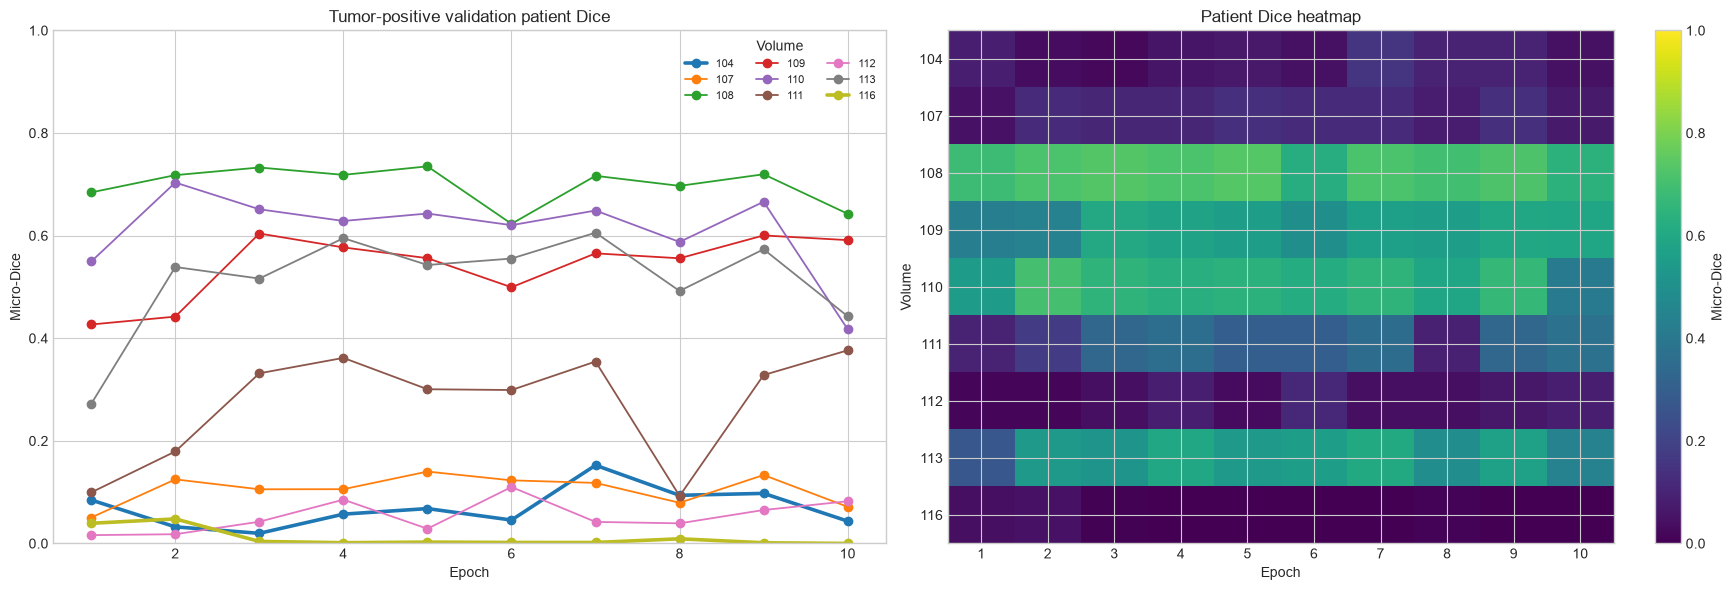

In [10]:
if patient_history_frame.empty:
    print("Patient history is unavailable.")
else:
    positive_patient_history = patient_history_frame.loc[
        patient_history_frame["true_pixels"].gt(0)
    ].copy()
    matrix = positive_patient_history.pivot(
        index="volume_id", columns="epoch", values="micro_dice"
    ).sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    for volume_id, group in positive_patient_history.groupby("volume_id"):
        linewidth = 2.6 if volume_id in {104, 116} else 1.3
        axes[0].plot(group["epoch"], group["micro_dice"], marker="o", linewidth=linewidth, label=str(volume_id))
    axes[0].set_ylim(0, 1); axes[0].set_title("Tumor-positive validation patient Dice")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Micro-Dice")
    axes[0].legend(title="Volume", ncol=3, fontsize=8)

    image = axes[1].imshow(matrix.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="viridis")
    axes[1].set_title("Patient Dice heatmap")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Volume")
    axes[1].set_xticks(range(len(matrix.columns)), matrix.columns)
    axes[1].set_yticks(range(len(matrix.index)), matrix.index)
    fig.colorbar(image, ax=axes[1], label="Micro-Dice")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "patient_dice_trajectories.png", dpi=160, bbox_inches="tight")
    plt.show()

### 9. Evaluate the best checkpoint, size quartiles, and threshold sensitivity

,value
best_epoch,7.000000
loss,0.483286
global_micro_dice,0.524200
pixel_precision,0.673402
pixel_recall,0.429121
positive_slice_recall,0.649712
positive_predicted_empty_pct,19.289827
empty_slice_false_positive_pct,17.826403
mean_patient_dice,0.356189
median_patient_dice,0.354597


,volume_id,micro_dice,true_pixels,predicted_pixels,positive_slices,positive_slice_recall,positive_predicted_empty_pct,empty_slice_false_positive_pct
0,104,1.524437e-01,69032,8741,122,0.245902,59.016393,8.042489
1,105,1.534684e-10,0,6516,0,0.000000,0.000000,22.920892
2,106,1.875821e-10,0,5331,0,0.000000,0.000000,17.120623
3,107,1.180223e-01,1473,9813,71,0.464789,26.760563,22.857143
4,108,7.166082e-01,363698,272566,202,0.876238,3.960396,10.550459
5,109,5.654799e-01,18200,34633,131,0.900763,3.053435,24.640000
6,110,6.489648e-01,31120,23940,130,0.876923,9.230769,9.183673
7,111,3.545969e-01,1830,4707,92,0.673913,7.608696,14.200299
8,112,4.199230e-02,295,8278,26,0.576923,7.692308,24.000000
9,113,6.057373e-01,21076,25601,135,0.837037,11.111111,8.844508


,size_quartile,slices,mean_dice,median_dice,detected_pct,predicted_empty_pct
0,Q1 smallest,263,0.287232,0.157895,53.992395,19.011407
1,Q2,258,0.418702,0.497781,70.542636,20.542636
2,Q3,260,0.470017,0.668674,70.769231,16.923077
3,Q4 largest,261,0.440492,0.668152,64.750958,20.689655


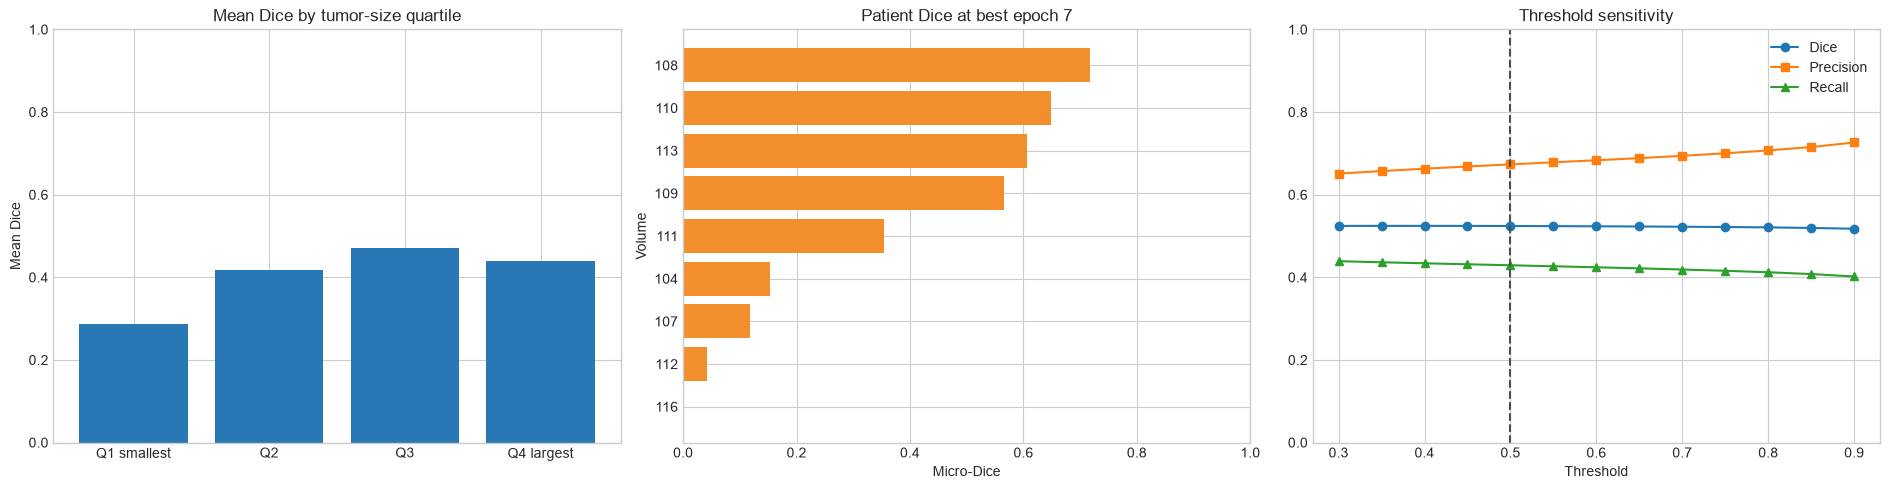

In [11]:
best_per_slice = pd.DataFrame()
best_patient_metrics = pd.DataFrame()
threshold_table = pd.DataFrame()
size_metrics = pd.DataFrame()

if best_checkpoint.is_file():
    best_payload = torch.load(best_checkpoint, map_location=device, weights_only=False)
    model.load_state_dict(best_payload["model_state"])
    best_epoch = int(best_payload["epoch"])
    final_result = evaluate_patient_aware(
        model, val_loader, criterion, device, FIXED_THRESHOLD, collect_rows=True
    )
    best_per_slice = pd.DataFrame(final_result.pop("rows"))
    best_patient_metrics = pd.DataFrame(final_result.pop("patient_rows"))
    best_per_slice.to_csv(OUTPUT_DIR / "best_validation_per_slice.csv", index=False)
    best_patient_metrics.to_csv(OUTPUT_DIR / "best_validation_patient_metrics.csv", index=False)

    positive_rows = best_per_slice.loc[best_per_slice["true_pixels"].gt(0)].copy()
    positive_rows["size_quartile"] = pd.qcut(
        positive_rows["true_pixels"], q=4,
        labels=["Q1 smallest", "Q2", "Q3", "Q4 largest"],
        duplicates="drop",
    )
    size_metrics = (
        positive_rows.groupby("size_quartile", observed=True)
        .agg(
            slices=("sample_id", "size"), mean_dice=("dice", "mean"),
            median_dice=("dice", "median"),
            detected_pct=("intersection_pixels", lambda x: 100 * (x > 0).mean()),
            predicted_empty_pct=("predicted_pixels", lambda x: 100 * (x == 0).mean()),
        )
        .reset_index()
    )
    size_metrics.to_csv(OUTPUT_DIR / "best_validation_size_quartiles.csv", index=False)
    display(pd.DataFrame([{"best_epoch": best_epoch, **final_result}]).T.rename(columns={0: "value"}))
    display(best_patient_metrics)
    display(size_metrics)

    accumulators = {
        float(t): {"intersection": 0, "predicted": 0, "actual": 0} for t in THRESHOLDS
    }
    model.eval()
    with torch.inference_mode():
        for batch in val_loader:
            images = batch["image"].to(device, non_blocking=True)
            truth = batch["mask"].to(device, non_blocking=True) >= 0.5
            probabilities = torch.sigmoid(model(images))
            for threshold, acc in accumulators.items():
                prediction = probabilities >= threshold
                acc["intersection"] += int((prediction & truth).sum())
                acc["predicted"] += int(prediction.sum())
                acc["actual"] += int(truth.sum())
    threshold_table = pd.DataFrame([
        {
            "threshold": threshold,
            "micro_dice": (2 * acc["intersection"] + 1e-6) / (acc["predicted"] + acc["actual"] + 1e-6),
            "precision": (acc["intersection"] + 1e-6) / (acc["predicted"] + 1e-6),
            "recall": (acc["intersection"] + 1e-6) / (acc["actual"] + 1e-6),
        }
        for threshold, acc in accumulators.items()
    ])
    threshold_table.to_csv(OUTPUT_DIR / "best_validation_threshold_sweep.csv", index=False)

    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    axes[0].bar(size_metrics["size_quartile"].astype(str), size_metrics["mean_dice"], color="#2878B5")
    axes[0].set_ylim(0, 1); axes[0].set_title("Mean Dice by tumor-size quartile")
    axes[0].set_xlabel(""); axes[0].set_ylabel("Mean Dice")

    positive_patients = best_patient_metrics.loc[best_patient_metrics["true_pixels"].gt(0)].sort_values("micro_dice")
    axes[1].barh(positive_patients["volume_id"].astype(str), positive_patients["micro_dice"], color="#F28E2B")
    axes[1].set_xlim(0, 1); axes[1].set_title(f"Patient Dice at best epoch {best_epoch}")
    axes[1].set_xlabel("Micro-Dice"); axes[1].set_ylabel("Volume")

    axes[2].plot(threshold_table["threshold"], threshold_table["micro_dice"], marker="o", label="Dice")
    axes[2].plot(threshold_table["threshold"], threshold_table["precision"], marker="s", label="Precision")
    axes[2].plot(threshold_table["threshold"], threshold_table["recall"], marker="^", label="Recall")
    axes[2].axvline(FIXED_THRESHOLD, linestyle="--", color="#4D4D4D")
    axes[2].set_ylim(0, 1); axes[2].set_title("Threshold sensitivity")
    axes[2].set_xlabel("Threshold"); axes[2].legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "best_model_diagnostics.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("Best checkpoint unavailable; run training first.")

### 10. Visualize worst, best, and key-patient predictions

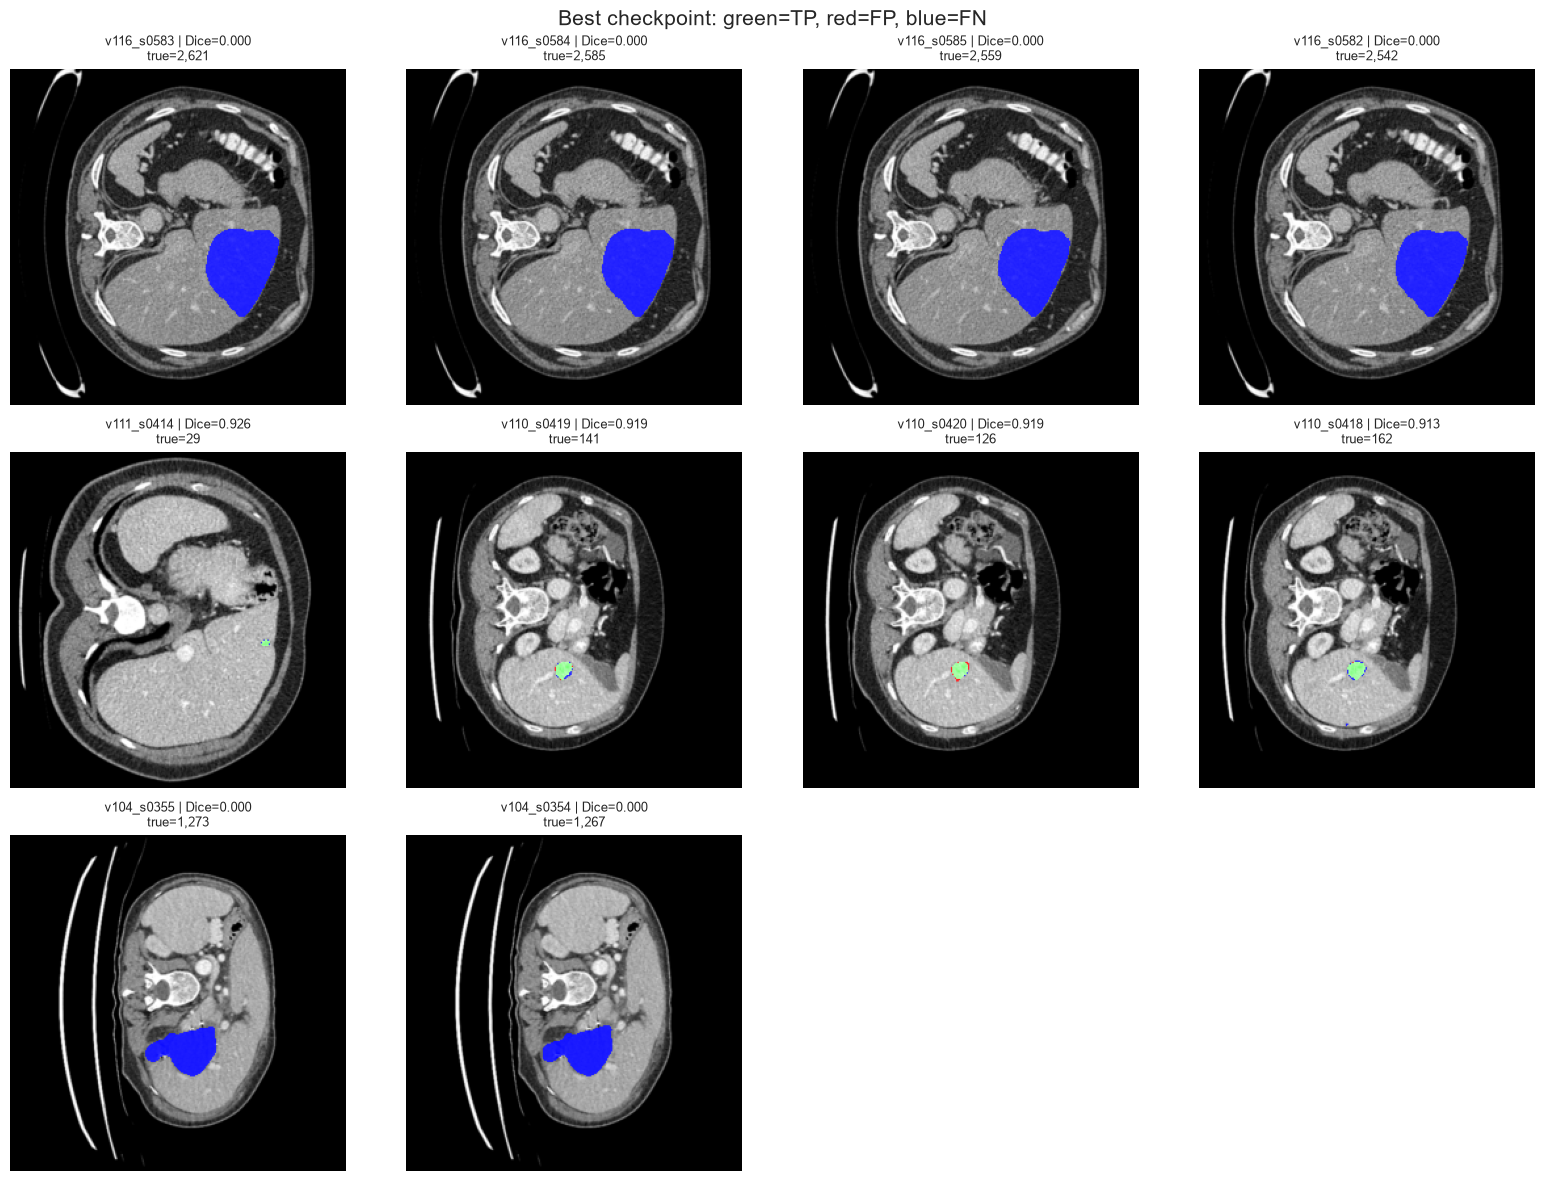

In [12]:
if not best_per_slice.empty:
    positive_rows = best_per_slice.loc[best_per_slice["true_pixels"].gt(0)]
    review_ids = []
    review_ids += positive_rows.nsmallest(4, "dice")["sample_id"].tolist()
    review_ids += positive_rows.nlargest(4, "dice")["sample_id"].tolist()
    for volume_id in [104, 116]:
        candidates = positive_rows.loc[positive_rows["volume_id"].eq(volume_id)]
        if len(candidates):
            review_ids += candidates.nlargest(2, "true_pixels")["sample_id"].tolist()
    review_ids = list(dict.fromkeys(review_ids))[:12]

    review_dataset = VerifiedManifestDataset(
        MANIFEST_PATH, split="val", root_dir=DATASET_ROOT,
        target="tumor", sample_ids=review_ids,
    )
    review_loader = DataLoader(review_dataset, batch_size=4, shuffle=False, num_workers=0)
    probabilities_by_id = {}
    model.eval()
    with torch.inference_mode():
        for batch in review_loader:
            probabilities = torch.sigmoid(model(batch["image"].to(device))).cpu().numpy()
            for index, sample_id in enumerate(batch["sample_id"]):
                probabilities_by_id[sample_id] = probabilities[index, 0]

    rows_count = math.ceil(len(review_dataset) / 4)
    fig, axes = plt.subplots(rows_count, 4, figsize=(16, 4 * rows_count))
    axes = np.atleast_1d(axes).ravel()
    for axis, item in zip(axes, review_dataset):
        sample_id = item["sample_id"]
        image = item["image"][0].numpy()
        truth = item["mask"][0].numpy().astype(bool)
        prediction = probabilities_by_id[sample_id] >= FIXED_THRESHOLD
        tp, fp, fn = prediction & truth, prediction & ~truth, truth & ~prediction
        rgb = np.repeat(image[..., None], 3, axis=2)
        rgb[tp, 1] = 1.0
        rgb[fp, 0] = 1.0; rgb[fp, 1:] *= 0.25
        rgb[fn, 2] = 1.0; rgb[fn, :2] *= 0.25
        row = best_per_slice.loc[best_per_slice["sample_id"].eq(sample_id)].iloc[0]
        axis.imshow(rgb)
        axis.set_title(f"{sample_id} | Dice={row['dice']:.3f}\ntrue={row['true_pixels']:,}", fontsize=9)
        axis.axis("off")
    for axis in axes[len(review_dataset):]:
        axis.axis("off")
    fig.suptitle("Best checkpoint: green=TP, red=FP, blue=FN", fontsize=15)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "best_model_prediction_errors.png", dpi=160, bbox_inches="tight")
    plt.show()

### Expanded process and error dashboard

The dashboard separates optimization progress, patient robustness, prediction
volume, false positives, confidence, and threshold behavior. It is regenerated
after every continuation session.

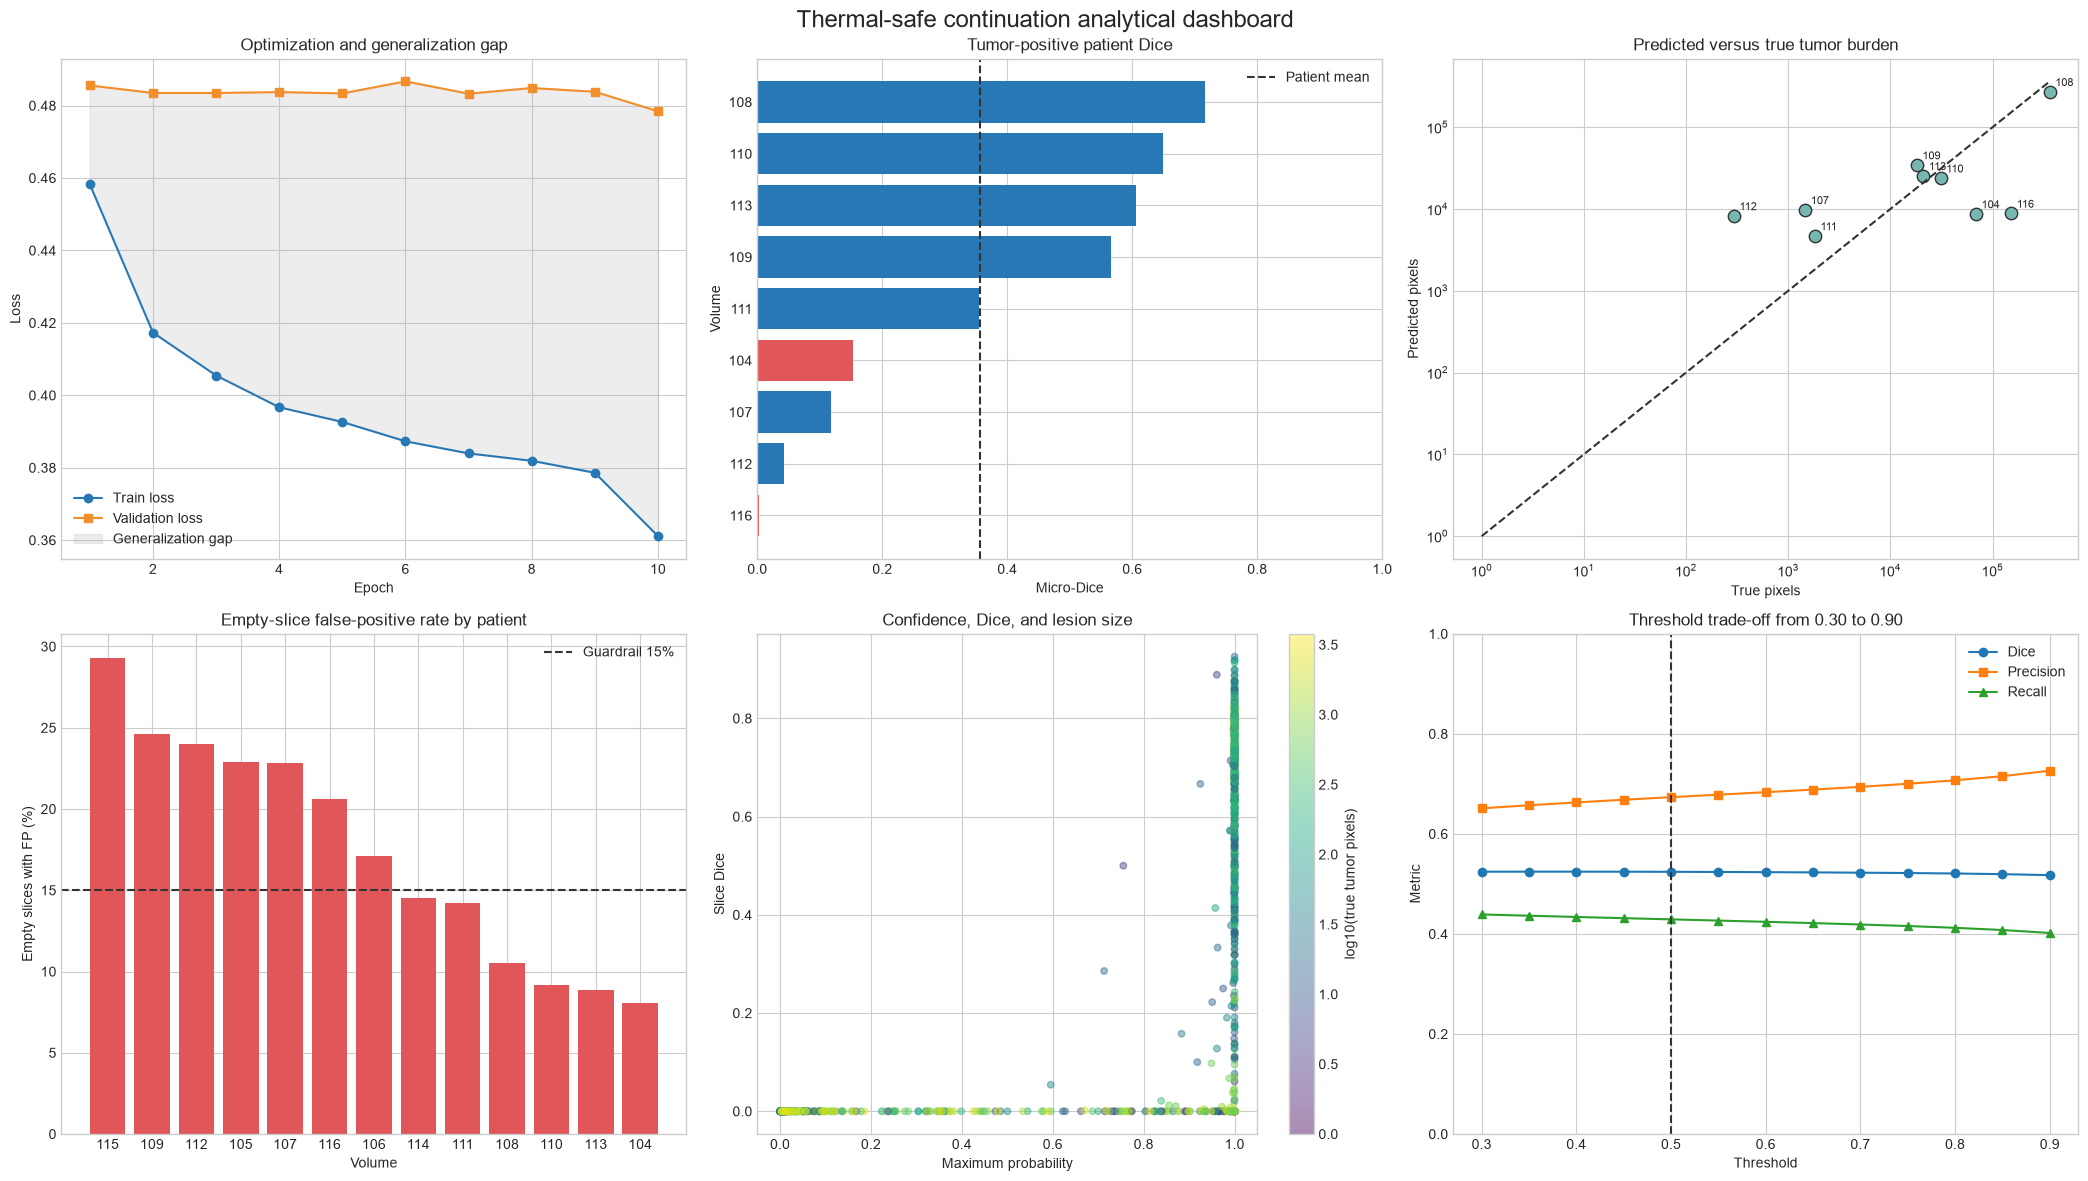

In [13]:

if history_frame.empty:
    print("Expanded dashboard is available after at least one completed epoch.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(21, 12))

    # 1. Generalization gap.
    axes[0, 0].plot(
        history_frame["epoch"], history_frame["train_loss"],
        marker="o", label="Train loss", color="#2878B5"
    )
    axes[0, 0].plot(
        history_frame["epoch"], history_frame["val_loss"],
        marker="s", label="Validation loss", color="#F28E2B"
    )
    axes[0, 0].fill_between(
        history_frame["epoch"],
        history_frame["train_loss"],
        history_frame["val_loss"],
        color="#B8B8B8", alpha=0.25, label="Generalization gap",
    )
    axes[0, 0].set_title("Optimization and generalization gap")
    axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()

    # 2. Patient distribution at the current best epoch.
    if not best_patient_metrics.empty:
        positive_patients = best_patient_metrics.loc[
            best_patient_metrics["true_pixels"].gt(0)
        ].sort_values("micro_dice")
        colors = [
            "#E15759" if volume in {104, 116} else "#2878B5"
            for volume in positive_patients["volume_id"]
        ]
        axes[0, 1].barh(
            positive_patients["volume_id"].astype(str),
            positive_patients["micro_dice"], color=colors
        )
        axes[0, 1].axvline(
            positive_patients["micro_dice"].mean(),
            linestyle="--", color="#333333", label="Patient mean"
        )
        axes[0, 1].set_xlim(0, 1)
        axes[0, 1].set_title("Tumor-positive patient Dice")
        axes[0, 1].set_xlabel("Micro-Dice"); axes[0, 1].set_ylabel("Volume")
        axes[0, 1].legend()

        # 3. Predicted versus true burden by patient.
        max_pixels = max(
            positive_patients["true_pixels"].max(),
            positive_patients["predicted_pixels"].max(),
        )
        axes[0, 2].scatter(
            positive_patients["true_pixels"],
            positive_patients["predicted_pixels"],
            s=80, color="#76B7B2", edgecolor="#333333"
        )
        axes[0, 2].plot([1, max_pixels], [1, max_pixels], linestyle="--", color="#333333")
        for row in positive_patients.itertuples(index=False):
            axes[0, 2].annotate(
                str(row.volume_id), (row.true_pixels, row.predicted_pixels),
                xytext=(4, 4), textcoords="offset points", fontsize=8
            )
        axes[0, 2].set_xscale("log"); axes[0, 2].set_yscale("log")
        axes[0, 2].set_title("Predicted versus true tumor burden")
        axes[0, 2].set_xlabel("True pixels"); axes[0, 2].set_ylabel("Predicted pixels")

        # 4. False-positive rate for every patient.
        fp_sorted = best_patient_metrics.sort_values(
            "empty_slice_false_positive_pct", ascending=False
        )
        axes[1, 0].bar(
            fp_sorted["volume_id"].astype(str),
            fp_sorted["empty_slice_false_positive_pct"],
            color="#E15759",
        )
        axes[1, 0].axhline(15, linestyle="--", color="#333333", label="Guardrail 15%")
        axes[1, 0].set_title("Empty-slice false-positive rate by patient")
        axes[1, 0].set_xlabel("Volume"); axes[1, 0].set_ylabel("Empty slices with FP (%)")
        axes[1, 0].legend()

    # 5. Confidence versus Dice on tumor-positive slices.
    if not best_per_slice.empty:
        positive_slices = best_per_slice.loc[best_per_slice["true_pixels"].gt(0)]
        scatter = axes[1, 1].scatter(
            positive_slices["max_probability"], positive_slices["dice"],
            c=np.log10(positive_slices["true_pixels"].clip(lower=1)),
            cmap="viridis", alpha=0.45, s=22,
        )
        axes[1, 1].set_title("Confidence, Dice, and lesion size")
        axes[1, 1].set_xlabel("Maximum probability"); axes[1, 1].set_ylabel("Slice Dice")
        fig.colorbar(scatter, ax=axes[1, 1], label="log10(true tumor pixels)")

    # 6. Extended threshold trade-off.
    if not threshold_table.empty:
        axes[1, 2].plot(
            threshold_table["threshold"], threshold_table["micro_dice"],
            marker="o", label="Dice"
        )
        axes[1, 2].plot(
            threshold_table["threshold"], threshold_table["precision"],
            marker="s", label="Precision"
        )
        axes[1, 2].plot(
            threshold_table["threshold"], threshold_table["recall"],
            marker="^", label="Recall"
        )
        axes[1, 2].axvline(FIXED_THRESHOLD, linestyle="--", color="#333333")
        axes[1, 2].set_ylim(0, 1)
        axes[1, 2].set_title("Threshold trade-off from 0.30 to 0.90")
        axes[1, 2].set_xlabel("Threshold"); axes[1, 2].set_ylabel("Metric")
        axes[1, 2].legend()

    fig.suptitle("Thermal-safe continuation analytical dashboard", fontsize=17)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "continuation_expanded_dashboard.png", dpi=160, bbox_inches="tight")
    plt.show()


### Thermal cooldown profile

This graph shows how long the GPU waited before each epoch and whether cooling
behavior is stable across the continuation run.

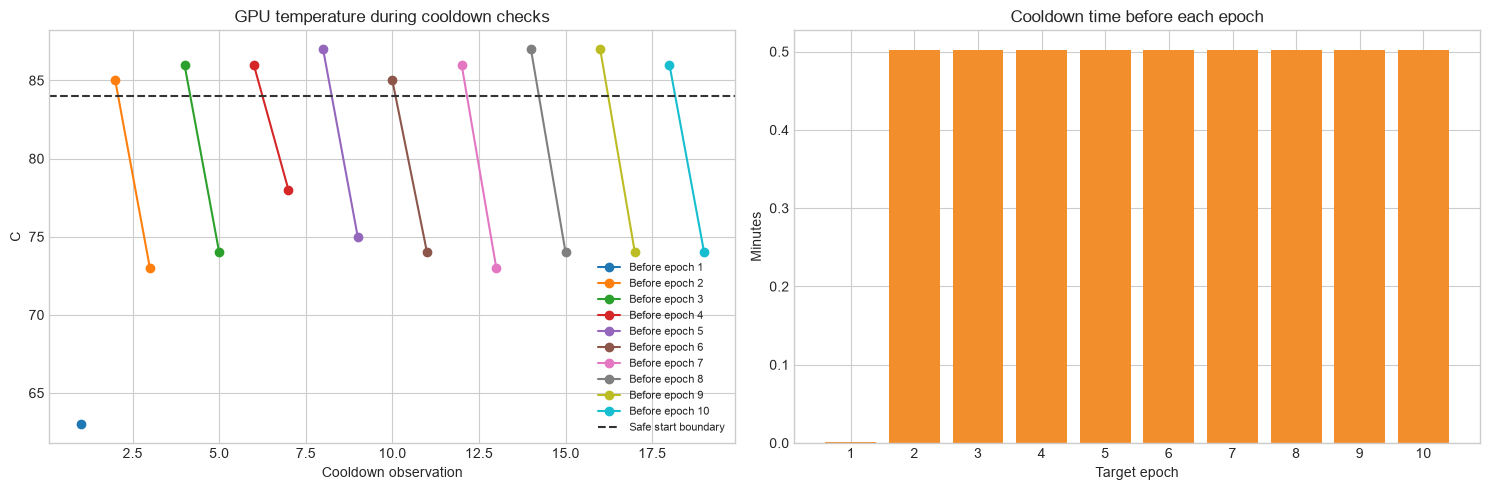

In [14]:

thermal_log_path = OUTPUT_DIR / "thermal_cooldown_log.csv"
if thermal_log_path.is_file():
    thermal_log = pd.read_csv(thermal_log_path)
    thermal_log["sequence"] = np.arange(1, len(thermal_log) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for epoch, group in thermal_log.groupby("target_epoch"):
        axes[0].plot(
            group["sequence"], group["temperature_c"],
            marker="o", label=f"Before epoch {epoch}"
        )
    axes[0].axhline(
        MAX_START_GPU_TEMP_C, linestyle="--", color="#333333",
        label="Safe start boundary"
    )
    axes[0].set_title("GPU temperature during cooldown checks")
    axes[0].set_xlabel("Cooldown observation"); axes[0].set_ylabel("C")
    axes[0].legend(fontsize=8)

    final_wait = (
        thermal_log.groupby("target_epoch")["cooldown_elapsed_seconds"]
        .max().reset_index()
    )
    axes[1].bar(
        final_wait["target_epoch"].astype(str),
        final_wait["cooldown_elapsed_seconds"] / 60,
        color="#F28E2B",
    )
    axes[1].set_title("Cooldown time before each epoch")
    axes[1].set_xlabel("Target epoch"); axes[1].set_ylabel("Minutes")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "thermal_cooldown_profile.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("Thermal cooldown log will appear when continuation training starts.")


### Baseline comparison dashboard

Compare the sampler ablation with the frozen epoch-10 baseline using validation
metrics only. The test split remains locked.


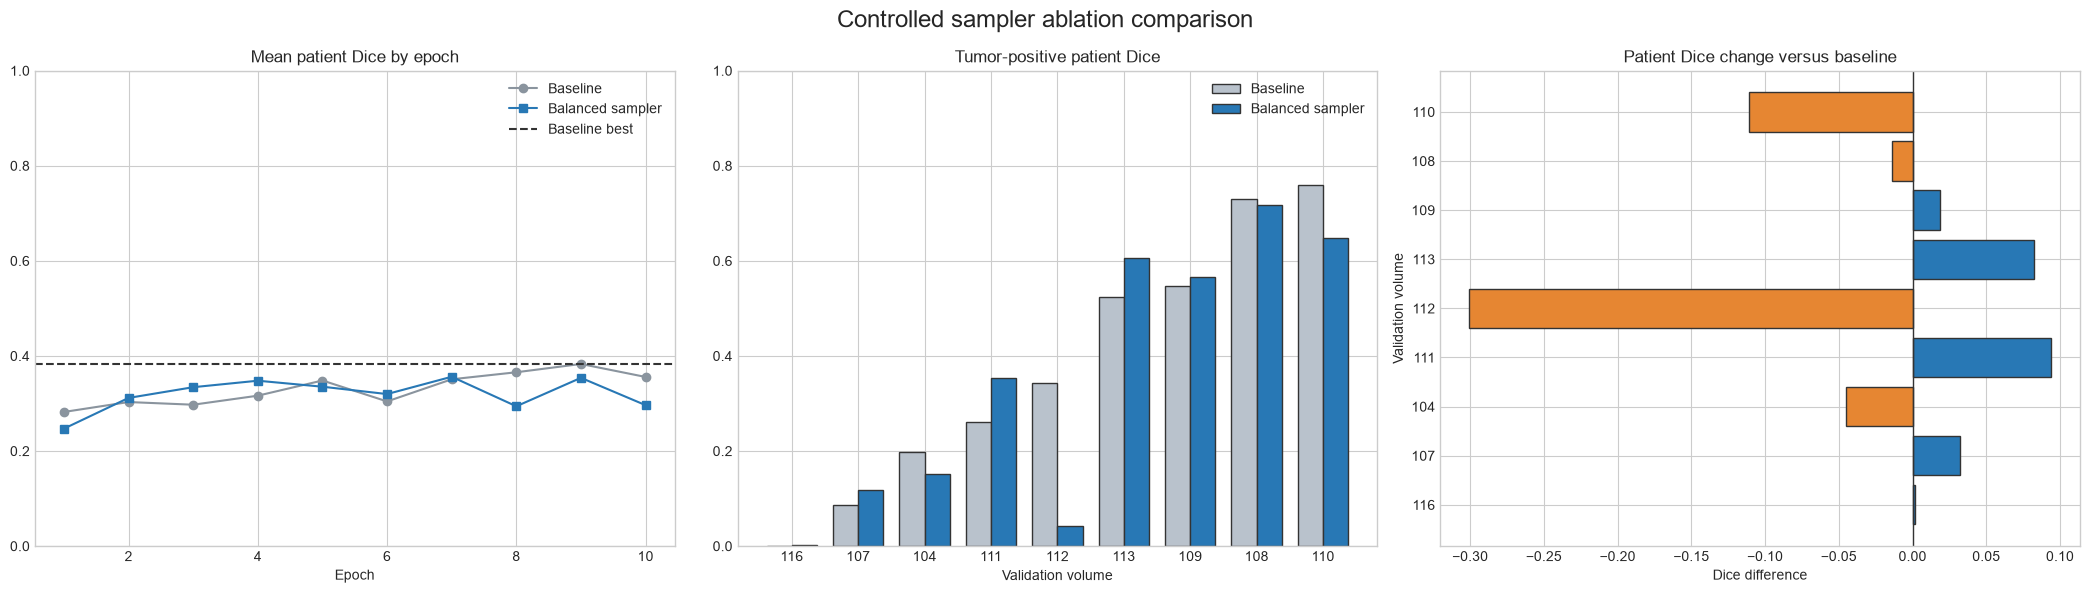

,metric,Baseline,Balanced sampler
0,Global micro Dice,0.5584,0.5242
1,Mean patient Dice,0.3831,0.3562
2,Median patient Dice,0.3426,0.3546
3,Positive predicted empty (%),39.4434,19.2898
4,Empty-slice FP (%),3.3496,17.8264


In [15]:
baseline_history = pd.read_csv(
    BASELINE_OUTPUT_DIR / "patient_aware_history.csv"
)
baseline_patients = pd.read_csv(
    BASELINE_OUTPUT_DIR / "best_validation_patient_metrics.csv"
)

if not history_frame.empty and not best_patient_metrics.empty:
    baseline_best = baseline_history.loc[
        baseline_history["val_mean_patient_dice"].idxmax()
    ]
    ablation_best = history_frame.loc[
        history_frame["val_mean_patient_dice"].idxmax()
    ]
    metric_comparison = pd.DataFrame({
        "metric": [
            "Global micro Dice", "Mean patient Dice", "Median patient Dice",
            "Positive predicted empty (%)", "Empty-slice FP (%)",
        ],
        "Baseline": [
            baseline_best["val_global_micro_dice"],
            baseline_best["val_mean_patient_dice"],
            baseline_best["val_median_patient_dice"],
            baseline_best["val_positive_predicted_empty_pct"],
            baseline_best["val_empty_slice_false_positive_pct"],
        ],
        "Balanced sampler": [
            ablation_best["val_global_micro_dice"],
            ablation_best["val_mean_patient_dice"],
            ablation_best["val_median_patient_dice"],
            ablation_best["val_positive_predicted_empty_pct"],
            ablation_best["val_empty_slice_false_positive_pct"],
        ],
    })

    patient_comparison = (
        baseline_patients[["volume_id", "micro_dice"]]
        .rename(columns={"micro_dice": "Baseline"})
        .merge(
            best_patient_metrics[["volume_id", "micro_dice"]].rename(
                columns={"micro_dice": "Balanced sampler"}
            ),
            on="volume_id", how="inner",
        )
    )
    patient_comparison = patient_comparison.loc[
        patient_comparison["volume_id"].isin([104, 107, 108, 109, 110, 111, 112, 113, 116])
    ].sort_values("Baseline")

    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    axes[0].plot(
        baseline_history["epoch"], baseline_history["val_mean_patient_dice"],
        marker="o", color="#8A949E", label="Baseline",
    )
    axes[0].plot(
        history_frame["epoch"], history_frame["val_mean_patient_dice"],
        marker="s", color="#2878B5", label="Balanced sampler",
    )
    axes[0].axhline(
        baseline_best["val_mean_patient_dice"], linestyle="--",
        color="#333333", label="Baseline best",
    )
    axes[0].set_title("Mean patient Dice by epoch")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylim(0, 1); axes[0].legend()

    x = np.arange(len(patient_comparison))
    width = 0.38
    axes[1].bar(
        x - width / 2, patient_comparison["Baseline"], width,
        color="#B9C2CC", edgecolor="#333333", label="Baseline",
    )
    axes[1].bar(
        x + width / 2, patient_comparison["Balanced sampler"], width,
        color="#2878B5", edgecolor="#333333", label="Balanced sampler",
    )
    axes[1].set_xticks(x, patient_comparison["volume_id"].astype(str))
    axes[1].set_title("Tumor-positive patient Dice")
    axes[1].set_xlabel("Validation volume"); axes[1].set_ylim(0, 1); axes[1].legend()

    delta = patient_comparison["Balanced sampler"] - patient_comparison["Baseline"]
    axes[2].barh(
        patient_comparison["volume_id"].astype(str), delta,
        color=np.where(delta >= 0, "#2878B5", "#E68632"),
        edgecolor="#333333",
    )
    axes[2].axvline(0, color="#333333", linewidth=1)
    axes[2].set_title("Patient Dice change versus baseline")
    axes[2].set_xlabel("Dice difference"); axes[2].set_ylabel("Validation volume")

    fig.suptitle("Controlled sampler ablation comparison", fontsize=17)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "baseline_comparison_dashboard.png", dpi=160, bbox_inches="tight")
    plt.show()
    display(metric_comparison.style.format({"Baseline": "{:.4f}", "Balanced sampler": "{:.4f}"}))
else:
    print("Comparison is available after training and best-checkpoint evaluation.")


## Takeaways

This is a controlled sampler ablation. Do not promote the model because global
Dice alone improves. The sampler must improve the mean patient score, patient
116, and smallest-lesion detection without breaking the false-positive
guardrail.


In [16]:
minimum_decision_epoch_reached = (
    not history_frame.empty
    and int(history_frame["epoch"].max()) >= MIN_EPOCHS_BEFORE_EARLY_STOP
)
baseline_gate_path = BASELINE_OUTPUT_DIR / "patient_aware_gate_result.json"
baseline_gate = json.loads(baseline_gate_path.read_text(encoding="utf-8"))

if not minimum_decision_epoch_reached:
    completed_epochs = int(history_frame["epoch"].max()) if not history_frame.empty else 0
    final_gate = {
        "status": "incomplete_continue_to_epoch_10",
        "epochs_completed": completed_epochs,
        "minimum_decision_epoch": MIN_EPOCHS_BEFORE_EARLY_STOP,
        "sampler_strategy": SAMPLER_STRATEGY,
        "test_images_accessed": False,
        "decision": f"INCOMPLETE — continue from epoch {completed_epochs + 1}.",
    }
elif best_patient_metrics.empty or size_metrics.empty:
    final_gate = {
        "status": "not_run",
        "sampler_strategy": SAMPLER_STRATEGY,
        "test_images_accessed": False,
        "decision": "Run training and best-checkpoint evaluation.",
    }
else:
    best_row = history_frame.loc[history_frame["val_mean_patient_dice"].idxmax()]
    positive_patients = best_patient_metrics.loc[best_patient_metrics["true_pixels"].gt(0)]
    volume_104 = positive_patients.loc[positive_patients["volume_id"].eq(104), "micro_dice"]
    volume_116 = positive_patients.loc[positive_patients["volume_id"].eq(116), "micro_dice"]
    q1 = size_metrics.loc[
        size_metrics["size_quartile"].eq("Q1 smallest")
    ].iloc[0]

    mean_improved = float(best_row["val_mean_patient_dice"]) > float(
        baseline_gate["best_mean_patient_dice"]
    )
    volume_104_preserved = bool(
        len(volume_104)
        and float(volume_104.iloc[0]) >= float(baseline_gate["volume_104_dice"])
    )
    volume_116_recovered = bool(len(volume_116) and float(volume_116.iloc[0]) > 0.05)
    q1_detection_improved = float(q1["detected_pct"]) > 35.0
    detection_guardrails = bool(
        float(best_row["val_positive_predicted_empty_pct"]) < 30.0
        and float(best_row["val_empty_slice_false_positive_pct"]) < 15.0
    )
    ready = all([
        mean_improved, volume_104_preserved, volume_116_recovered,
        q1_detection_improved, detection_guardrails,
    ])
    final_gate = {
        "status": "sampler_ablation_pass" if ready else "sampler_ablation_fail",
        "manifest_sha256": manifest_hash,
        "sampler_strategy": SAMPLER_STRATEGY,
        "epochs_completed": int(history_frame["epoch"].max()),
        "best_epoch": int(best_row["epoch"]),
        "best_global_micro_dice": float(best_row["val_global_micro_dice"]),
        "best_mean_patient_dice": float(best_row["val_mean_patient_dice"]),
        "baseline_mean_patient_dice": float(baseline_gate["best_mean_patient_dice"]),
        "volume_104_dice": float(volume_104.iloc[0]) if len(volume_104) else None,
        "volume_116_dice": float(volume_116.iloc[0]) if len(volume_116) else None,
        "q1_smallest_detected_pct": float(q1["detected_pct"]),
        "positive_predicted_empty_pct": float(best_row["val_positive_predicted_empty_pct"]),
        "empty_slice_false_positive_pct": float(best_row["val_empty_slice_false_positive_pct"]),
        "mean_patient_improved": mean_improved,
        "volume_104_preserved": volume_104_preserved,
        "volume_116_recovered": volume_116_recovered,
        "q1_detection_improved": q1_detection_improved,
        "detection_guardrails_pass": detection_guardrails,
        "test_images_accessed": False,
        "decision": (
            "PASS — retain balanced sampling for the next loss ablation."
            if ready else
            "FAIL — balanced sampling alone is insufficient; keep the better baseline and test a recall-aware loss."
        ),
    }

(OUTPUT_DIR / "sampler_ablation_gate_result.json").write_text(
    json.dumps(final_gate, indent=2), encoding="utf-8"
)
display(pd.DataFrame([final_gate]).T.rename(columns={0: "result"}))
print(final_gate["decision"])


,result
status,sampler_ablation_fail
manifest_sha256,575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63...
sampler_strategy,inverse_volume_x_lesion_quartile_v1
epochs_completed,10
best_epoch,7
best_global_micro_dice,0.5242
best_mean_patient_dice,0.356189
baseline_mean_patient_dice,0.383069
volume_104_dice,0.152444
volume_116_dice,0.001856


FAIL — balanced sampling alone is insufficient; keep the better baseline and test a recall-aware loss.


### Interpretation guide

- If patient mean improves and volumes 104/116 become nonzero, the longer
  baseline has addressed the main smoke-test failure.
- If global Dice rises while patient mean remains flat, the model is still
  dominated by high-burden patients.
- If volume 116 remains near zero after 10–15 epochs, stop and consider a
  liver-first or multitask liver/tumor strategy.
- If false positives rise, reduce positive sampling or strengthen negative
  exposure before changing the decision threshold.
- Threshold curves are diagnostic only. Do not touch the test split until the
  architecture, stopping rule, sampling, loss, and threshold-selection
  procedure are frozen.